# STAT 5243 Final Project — NYC Taxi Congestion Pricing



# Part 1 — Data Preprocessing

## 1. Setup

This section defines paths, constants, and a quick raw-file check before the heavy pipeline runs.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
from IPython.display import display

# Find the project root automatically so the notebook works from different folders.
PROJECT_ROOT = next(
    p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (p / "data" / "raw").exists() or (p / "data" / "processed").exists()
)
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# Use four months so we cover both pre-policy and post-policy periods.
MONTH_FILES = {
    "2024-11": "yellow_tripdata_2024-11.parquet",
    "2024-12": "yellow_tripdata_2024-12.parquet",
    "2025-01": "yellow_tripdata_2025-01.parquet",
    "2025-02": "yellow_tripdata_2025-02.parquet",
}

RAW_FILES = {
    "zones": "taxi_zone_lookup.csv",
    "weather": "weather_hourly.csv",
    "holidays": "us_holidays.csv",
}

ALLOWED_PAYMENT_TYPES = {1, 2, 3, 4}
PROJECT_START = pd.Timestamp("2024-11-01")
PROJECT_END = pd.Timestamp("2025-03-01")
# This is the official congestion pricing start date.
POLICY_START = pd.Timestamp("2025-01-05").date()

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def print_progress(message: str) -> None:
    print(f"[data-pipeline] {message}")

required_paths = [RAW_DIR / filename for filename in MONTH_FILES.values()]
required_paths.extend(RAW_DIR / filename for filename in RAW_FILES.values())
available_raw_files = sorted(path.name for path in RAW_DIR.glob("*")) if RAW_DIR.exists() else []
# Check missing files before running expensive reads.
missing_raw_files = [path.name for path in required_paths if not path.exists()]

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw files available: {available_raw_files}")
if missing_raw_files:
    print("Missing raw files:", missing_raw_files)
else:
    print("All required raw files are present.")

Project root: /Users/jason/Documents/5243 final project
Raw files available: ['taxi_zone_lookup.csv', 'us_holidays.csv', 'weather_hourly.csv', 'yellow_tripdata_2024-11.parquet', 'yellow_tripdata_2024-12.parquet', 'yellow_tripdata_2025-01.parquet', 'yellow_tripdata_2025-02.parquet']
All required raw files are present.


## 2. Utility Functions

These helpers keep the pipeline readable and make the cleaning log reproducible.

In [2]:
def require_files(paths: Iterable[Path]) -> None:
    missing = [str(path) for path in paths if not path.exists()]
    if missing:
        missing_text = "\n".join(f"- {item}" for item in missing)
        raise FileNotFoundError(f"Missing required input files:\n{missing_text}")


def append_log(log_rows: list[dict[str, float]], step: str, before: int, after: int) -> None:
    # Track how many rows each cleaning rule removes.
    dropped = before - after
    percent_dropped = (dropped / before * 100.0) if before else 0.0
    log_rows.append(
        {
            "step_name": step,
            "rows_before": before,
            "rows_after": after,
            "rows_dropped": dropped,
            "percent_dropped": round(percent_dropped, 4),
        }
    )


def filter_rows(
    df: pd.DataFrame,
    drop_mask: pd.Series,
    step: str,
    log_rows: list[dict[str, float]],
) -> pd.DataFrame:
    before = len(df)
    # The mask marks bad rows, so keep the opposite rows.
    cleaned = df.loc[~drop_mask].copy()
    append_log(log_rows, step, before, len(cleaned))
    print_progress(f"{step}: dropped {before - len(cleaned):,} rows; remaining {len(cleaned):,}")
    return cleaned


def detect_first_matching_column(df: pd.DataFrame, candidates: list[str], label: str) -> str:
    for column in candidates:
        if column in df.columns:
            return column
    raise ValueError(f"Could not find a {label} column. Available columns: {list(df.columns)}")


def rename_first_available(
    df: pd.DataFrame,
    candidate_map: dict[str, list[str]],
) -> tuple[pd.DataFrame, list[str]]:
    selected: list[str] = []
    rename_map: dict[str, str] = {}
    # Some files use different column names, so pick the first available alias.
    for target_name, candidates in candidate_map.items():
        for candidate in candidates:
            if candidate in df.columns:
                rename_map[candidate] = target_name
                selected.append(target_name)
                break
    renamed = df.rename(columns=rename_map)
    return renamed, selected


def downcast_numeric_columns(df: pd.DataFrame) -> pd.DataFrame:
    integer_columns = df.select_dtypes(include=["int64", "Int64"]).columns
    float_columns = df.select_dtypes(include=["float64"]).columns

    for column in integer_columns:
        df[column] = pd.to_numeric(df[column], downcast="integer")

    for column in float_columns:
        df[column] = pd.to_numeric(df[column], downcast="float")

    for column in [
        "source_month",
        "store_and_fwd_flag",
        "PUBorough",
        "DOBorough",
        "PUZone",
        "DOZone",
    ]:
        if column in df.columns:
            df[column] = df[column].astype("category")

    return df


def markdown_table_from_dataframe(df: pd.DataFrame) -> str:
    if df.empty:
        return "_No rows_\n"

    headers = list(df.columns)
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]

    for _, row in df.iterrows():
        values = [str(row[column]) for column in headers]
        lines.append("| " + " | ".join(values) + " |")

    return "\n".join(lines) + "\n"

## 3. Cleaning Functions



In [3]:
def load_monthly_taxi_data(raw_dir: Path) -> tuple[pd.DataFrame, dict[str, int]]:
    frames: list[pd.DataFrame] = []
    source_counts: dict[str, int] = {}

    # Load each month separately so source-month counts are preserved.
    for source_month, filename in MONTH_FILES.items():
        path = raw_dir / filename
        print_progress(f"Loading {path.relative_to(raw_dir.parent)}")
        monthly = pd.read_parquet(path)
        monthly["source_month"] = source_month

        # Older files may not have this column, so add it before concatenation.
        if "cbd_congestion_fee" not in monthly.columns:
            monthly["cbd_congestion_fee"] = 0.0

        # The CBD fee did not exist before 2025, so pre-policy months are set to zero.
        if source_month in {"2024-11", "2024-12"}:
            monthly["cbd_congestion_fee"] = 0.0

        source_counts[source_month] = len(monthly)
        frames.append(monthly)

    # Combine all months into one trip-level dataframe.
    combined = pd.concat(frames, ignore_index=True)
    source_counts["combined"] = len(combined)
    print_progress(f"Combined monthly files into {len(combined):,} rows")
    return combined, source_counts


def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    rename_map = {
        "tpep_pickup_datetime": "pickup_datetime",
        "tpep_dropoff_datetime": "dropoff_datetime",
        "VendorID": "vendor_id",
        "RatecodeID": "ratecode_id",
        "Airport_fee": "airport_fee",
    }
    # Standard names make later code easier to read.
    standardized = df.rename(columns=rename_map)
    print_progress("Standardized required column names")
    return standardized


def clean_trip_data(df: pd.DataFrame) -> tuple[pd.DataFrame, list[dict[str, float]], dict[str, int]]:
    log_rows: list[dict[str, float]] = []
    imputation_summary = {
        "filled_passenger_count": 0,
        "cbd_fee_negatives_reset": 0,
        "dropped_missing_core_fields": 0,
    }

    print_progress("Parsing datetime columns")
    # Convert datetime columns before duration and date filtering.
    df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"], errors="coerce")
    df["dropoff_datetime"] = pd.to_datetime(df["dropoff_datetime"], errors="coerce")

    required_core = [
        "pickup_datetime",
        "dropoff_datetime",
        "trip_distance",
        "fare_amount",
        "tip_amount",
        "payment_type",
        "PULocationID",
        "DOLocationID",
    ]
    missing_core_mask = df[required_core].isna().any(axis=1)
    imputation_summary["dropped_missing_core_fields"] = int(missing_core_mask.sum())
    df = filter_rows(df, missing_core_mask, "drop_missing_core_fields", log_rows)

    df = filter_rows(
        df,
        (df["pickup_datetime"] < PROJECT_START) | (df["pickup_datetime"] >= PROJECT_END),
        "drop_pickup_outside_project_window",
        log_rows,
    )

    df = filter_rows(
        df,
        df["dropoff_datetime"] <= df["pickup_datetime"],
        "drop_non_positive_trip_time",
        log_rows,
    )

    # Trip duration is used for cleaning and later modeling features.
    df["duration_minutes"] = (
        (df["dropoff_datetime"] - df["pickup_datetime"]).dt.total_seconds() / 60.0
    )

    df = filter_rows(df, df["duration_minutes"] < 1, "drop_duration_lt_1_minute", log_rows)
    df = filter_rows(df, df["duration_minutes"] > 360, "drop_duration_gt_360_minutes", log_rows)

    df = filter_rows(
        df,
        (df["trip_distance"] <= 0) & (df["fare_amount"] > 0),
        "drop_non_positive_distance_positive_fare",
        log_rows,
    )
    df = filter_rows(df, df["trip_distance"] > 100, "drop_distance_gt_100_miles", log_rows)

    df["avg_speed_mph"] = df["trip_distance"] / (df["duration_minutes"] / 60.0)
    df = filter_rows(df, df["avg_speed_mph"] > 80, "drop_avg_speed_gt_80_mph", log_rows)

    df = filter_rows(df, df["fare_amount"] < 0, "drop_negative_fare", log_rows)
    df = filter_rows(df, df["fare_amount"] == 0, "drop_zero_fare", log_rows)
    df = filter_rows(df, df["fare_amount"] > 500, "drop_fare_gt_500", log_rows)
    df = filter_rows(df, df["tip_amount"] < 0, "drop_negative_tip", log_rows)

    # Negative fee values are data errors, so reset them to zero.
    negative_cbd_mask = df["cbd_congestion_fee"] < 0
    imputation_summary["cbd_fee_negatives_reset"] = int(negative_cbd_mask.sum())
    if imputation_summary["cbd_fee_negatives_reset"] > 0:
        df.loc[negative_cbd_mask, "cbd_congestion_fee"] = 0.0
        print_progress(
            f"Reset {imputation_summary['cbd_fee_negatives_reset']:,} negative cbd_congestion_fee values to 0"
        )

    passenger_fill_mask = df["passenger_count"].isna() | (df["passenger_count"] == 0)
    imputation_summary["filled_passenger_count"] = int(passenger_fill_mask.sum())
    if imputation_summary["filled_passenger_count"] > 0:
        df.loc[passenger_fill_mask, "passenger_count"] = 1
        print_progress(
            f"Filled {imputation_summary['filled_passenger_count']:,} passenger_count values with 1"
        )

    df = filter_rows(df, df["passenger_count"] > 6, "drop_passenger_count_gt_6", log_rows)
    df = filter_rows(
        df,
        df["PULocationID"].isin([264, 265]) | df["DOLocationID"].isin([264, 265]),
        "drop_unknown_location_ids_264_265",
        log_rows,
    )
    df = filter_rows(df, ~df["payment_type"].isin(ALLOWED_PAYMENT_TYPES), "drop_invalid_payment_type", log_rows)

    print_progress("Creating derived columns")
    # Time features are useful for EDA and demand modeling.
    df["pickup_hour"] = df["pickup_datetime"].dt.hour.astype("Int16")
    df["pickup_dayofweek"] = df["pickup_datetime"].dt.dayofweek.astype("Int16")
    df["pickup_date"] = df["pickup_datetime"].dt.date
    # Tip percentage only makes sense when fare is positive.
    df["tip_pct"] = np.where(df["fare_amount"] > 0, df["tip_amount"] / df["fare_amount"], np.nan)
    df["post_congestion_fee"] = df["pickup_date"] >= POLICY_START

    return df, log_rows, imputation_summary

## 4. Join, Validation, and Save Functions


In [4]:
def join_taxi_zones(df: pd.DataFrame, zone_path: Path) -> pd.DataFrame:
    print_progress("Joining taxi zone lookup for pickup and dropoff")
    zones = pd.read_csv(zone_path)
    required_columns = {"LocationID", "Borough", "Zone"}
    if not required_columns.issubset(zones.columns):
        raise ValueError(
            f"taxi_zone_lookup.csv must contain {required_columns}; got {set(zones.columns)}"
        )

    # Add pickup borough and zone names.
    pickup_zones = zones[["LocationID", "Borough", "Zone"]].rename(
        columns={"LocationID": "PULocationID", "Borough": "PUBorough", "Zone": "PUZone"}
    )
    # Add dropoff borough and zone names.
    dropoff_zones = zones[["LocationID", "Borough", "Zone"]].rename(
        columns={"LocationID": "DOLocationID", "Borough": "DOBorough", "Zone": "DOZone"}
    )

    df = df.merge(pickup_zones, on="PULocationID", how="left")
    df = df.merge(dropoff_zones, on="DOLocationID", how="left")
    return df


def join_weather(df: pd.DataFrame, weather_path: Path) -> tuple[pd.DataFrame, list[str]]:
    print_progress("Joining hourly weather data")
    weather = pd.read_csv(weather_path)
    weather_time_column = detect_first_matching_column(
        weather,
        ["weather_datetime", "datetime", "time", "timestamp", "date_hour", "hour"],
        "weather datetime",
    )

    # Weather timestamps need to align with taxi pickup hours.
    weather[weather_time_column] = pd.to_datetime(weather[weather_time_column], errors="coerce")
    weather = weather.dropna(subset=[weather_time_column]).copy()
    weather[weather_time_column] = weather[weather_time_column].dt.floor("h")

    # Support common weather column names from different sources.
    weather_column_aliases = {
        "temperature": ["temperature", "temp", "temperature_2m"],
        "precipitation": ["precipitation", "precip", "prcp"],
        "snow": ["snow", "snowfall"],
        "humidity": ["humidity", "relative_humidity", "rhum"],
        "wind_speed": ["wind_speed", "windspeed", "wind_speed_10m", "wspd"],
    }

    weather, _ = rename_first_available(weather, weather_column_aliases)
    weather_features = ["temperature", "precipitation", "snow", "humidity", "wind_speed"]
    available_features = [column for column in weather_features if column in weather.columns]
    weather = weather[[weather_time_column, *available_features]].drop_duplicates(subset=[weather_time_column])
    weather = weather.rename(columns={weather_time_column: "pickup_hour_ts"})

    # Round pickup time down to the hour for the weather merge.
    df["pickup_hour_ts"] = df["pickup_datetime"].dt.floor("h")
    df = df.merge(weather, on="pickup_hour_ts", how="left")
    return df, available_features


def join_holidays(df: pd.DataFrame, holiday_path: Path) -> pd.DataFrame:
    print_progress("Joining holiday indicators")
    holidays = pd.read_csv(holiday_path)
    holiday_date_column = detect_first_matching_column(
        holidays,
        ["date", "holiday_date", "ds", "observed_date"],
        "holiday date",
    )

    holidays[holiday_date_column] = pd.to_datetime(holidays[holiday_date_column], errors="coerce")
    # Holiday matching only needs the pickup date.
    holiday_dates = set(holidays[holiday_date_column].dropna().dt.date.unique())
    df["is_holiday"] = df["pickup_date"].isin(holiday_dates)
    return df


def validate_dataset(df: pd.DataFrame, weather_columns: list[str]) -> dict[str, float]:
    print_progress("Running validation checks")
    checks: dict[str, float] = {}

    checks["fare_amount_le_0"] = int((df["fare_amount"] <= 0).sum())
    checks["duration_out_of_range"] = int(((df["duration_minutes"] < 1) | (df["duration_minutes"] > 360)).sum())
    checks["trip_distance_out_of_range"] = int(((df["trip_distance"] < 0.01) | (df["trip_distance"] > 100)).sum())
    checks["pu_location_out_of_range"] = int(((df["PULocationID"] < 1) | (df["PULocationID"] > 263)).sum())
    checks["do_location_out_of_range"] = int(((df["DOLocationID"] < 1) | (df["DOLocationID"] > 263)).sum())
    checks["missing_pu_borough"] = int(df["PUBorough"].isna().sum())
    checks["missing_do_borough"] = int(df["DOBorough"].isna().sum())

    if weather_columns:
        weather_missing_rate = df[weather_columns].isna().all(axis=1).mean()
    else:
        weather_missing_rate = 1.0
    checks["weather_missing_rate"] = float(weather_missing_rate)

    checks["nonzero_2024_cbd_fee"] = int(
        (df["source_month"].isin(["2024-11", "2024-12"]) & (df["cbd_congestion_fee"].fillna(0) != 0)).sum()
    )
    checks["missing_post_policy_cbd_fee"] = int(
        (df["source_month"].isin(["2025-01", "2025-02"]) & df["post_congestion_fee"] & df["cbd_congestion_fee"].isna()).sum()
    )

    # Run final checks before saving the cleaned dataset.
    failing_checks = {name: value for name, value in checks.items() if name != "weather_missing_rate" and value != 0}
    if failing_checks:
        details = ", ".join(f"{name}={value}" for name, value in failing_checks.items())
        raise ValueError(f"Validation failed: {details}")

    if weather_missing_rate > 0.01:
        print_progress(f"WARNING: weather missing rate is {weather_missing_rate:.2%}, above the 1% threshold")
    else:
        print_progress(f"Weather missing rate: {weather_missing_rate:.2%}")

    return checks


def write_data_quality_report(
    output_path: Path,
    source_counts: dict[str, int],
    cleaning_log: pd.DataFrame,
    imputation_summary: dict[str, int],
    weather_columns: list[str],
    validation_checks: dict[str, float],
    final_df: pd.DataFrame,
) -> None:
    cleaning_rules = [
        "Dropped rows outside pickup window [2024-11-01, 2025-03-01).",
        "Dropped trips with dropoff_datetime <= pickup_datetime.",
        "Dropped trips with duration_minutes < 1 or > 360.",
        "Dropped trips with trip_distance <= 0 and fare_amount > 0.",
        "Dropped trips with trip_distance > 100 or avg_speed_mph > 80.",
        "Dropped trips with fare_amount <= 0 or fare_amount > 500.",
        "Dropped trips with tip_amount < 0.",
        "Reset negative cbd_congestion_fee values to 0.",
        "Filled missing or zero passenger_count with 1, then dropped passenger_count > 6.",
        "Dropped rows with PULocationID or DOLocationID equal to 264 or 265.",
        "Dropped rows with payment_type outside {1, 2, 3, 4}.",
    ]

    imputation_lines = [
        f"- Filled missing/zero `passenger_count` with 1: {imputation_summary['filled_passenger_count']:,} rows",
        f"- Reset negative `cbd_congestion_fee` values to 0: {imputation_summary['cbd_fee_negatives_reset']:,} rows",
        f"- Dropped rows with missing core fields: {imputation_summary['dropped_missing_core_fields']:,} rows",
    ]

    join_lines = [
        "- Joined taxi zone lookup twice: pickup (`PUBorough`, `PUZone`) and dropoff (`DOBorough`, `DOZone`).",
        "- Joined hourly weather on pickup timestamp floored to the hour.",
        f"- Weather columns included: {', '.join(weather_columns) if weather_columns else 'none detected in weather_hourly.csv'}.",
        "- Added `is_holiday` by matching `pickup_date` against `us_holidays.csv`.",
    ]

    limitations = [
        "- `weather_missing_rate` above 1% should be investigated before downstream modeling.",
        "- `cbd_congestion_fee` post-policy validation only checks for non-missing values, not policy applicability by route.",
        "- The notebook assumes `weather_hourly.csv` and `us_holidays.csv` contain at least one parseable datetime/date column.",
    ]

    validation_df = pd.DataFrame([{"check": key, "value": value} for key, value in validation_checks.items()])

    report = f"""# Data Quality Report

## Source Files And Row Counts
{markdown_table_from_dataframe(pd.DataFrame([source_counts]))}

## Cleaning Rules
{chr(10).join(f'- {rule}' for rule in cleaning_rules)}

## Rows Removed At Each Step
{markdown_table_from_dataframe(cleaning_log)}

## Imputation Decisions
{chr(10).join(imputation_lines)}

## Joins Performed
{chr(10).join(join_lines)}

## Validation Summary
{markdown_table_from_dataframe(validation_df)}

## Final Dataset
- Rows: {len(final_df):,}
- Columns: {len(final_df.columns):,}
- Primary output file: `data/processed/clean_trips.parquet`
- CSV export: `data/processed/clean_trips.csv`

## Known Limitations
{chr(10).join(limitations)}
"""

    output_path.write_text(report, encoding="utf-8")


def run_pipeline() -> dict[str, object]:
    require_files(required_paths)

    taxi_df, source_counts = load_monthly_taxi_data(RAW_DIR)
    taxi_df = standardize_columns(taxi_df)
    taxi_df, log_rows, imputation_summary = clean_trip_data(taxi_df)
    taxi_df = join_taxi_zones(taxi_df, RAW_DIR / RAW_FILES["zones"])
    taxi_df, weather_columns = join_weather(taxi_df, RAW_DIR / RAW_FILES["weather"])
    taxi_df = join_holidays(taxi_df, RAW_DIR / RAW_FILES["holidays"])
    validation_checks = validate_dataset(taxi_df, weather_columns)
    taxi_df = downcast_numeric_columns(taxi_df)

    cleaning_log = pd.DataFrame(log_rows)
    cleaning_log_path = PROCESSED_DIR / "cleaning_log.csv"
    parquet_path = PROCESSED_DIR / "clean_trips.parquet"
    csv_path = PROCESSED_DIR / "clean_trips.csv"
    report_path = PROCESSED_DIR / "data_quality_report.md"

    print_progress(f"Saving cleaned dataset to {parquet_path.relative_to(PROJECT_ROOT)}")
    # Parquet with snappy is compact and fast to reload.
    taxi_df.to_parquet(parquet_path, index=False, compression="snappy")

    print_progress(f"Saving CSV export to {csv_path.relative_to(PROJECT_ROOT)}")
    taxi_df.to_csv(csv_path, index=False)

    print_progress(f"Saving cleaning log to {cleaning_log_path.relative_to(PROJECT_ROOT)}")
    cleaning_log.to_csv(cleaning_log_path, index=False)

    print_progress(f"Saving data quality report to {report_path.relative_to(PROJECT_ROOT)}")
    write_data_quality_report(
        output_path=report_path,
        source_counts=source_counts,
        cleaning_log=cleaning_log,
        imputation_summary=imputation_summary,
        weather_columns=weather_columns,
        validation_checks=validation_checks,
        final_df=taxi_df,
    )

    print_progress(
        f"Pipeline completed successfully with {len(taxi_df):,} rows and {len(taxi_df.columns):,} columns"
    )

    return {
        "clean_df": taxi_df,
        "cleaning_log": cleaning_log,
        "source_counts": source_counts,
        "validation_checks": validation_checks,
        "parquet_path": parquet_path,
        "csv_path": csv_path,
        "cleaning_log_path": cleaning_log_path,
        "report_path": report_path,
    }

## 5. Run The Pipeline



In [5]:
results = None

if missing_raw_files:
    print("Cannot run the pipeline until the missing raw files are added to data/raw/.")
else:
    results = run_pipeline()
    summary = pd.DataFrame([results["source_counts"]])
    display(summary)
    display(results["cleaning_log"])
    display(pd.DataFrame([results["validation_checks"]]))
    display(results["clean_df"].head())
    print("\nSaved files:")
    print(f"- {results['parquet_path']}")
    print(f"- {results['csv_path']}")
    print(f"- {results['cleaning_log_path']}")
    print(f"- {results['report_path']}")

[data-pipeline] Loading raw/yellow_tripdata_2024-11.parquet
[data-pipeline] Loading raw/yellow_tripdata_2024-12.parquet
[data-pipeline] Loading raw/yellow_tripdata_2025-01.parquet
[data-pipeline] Loading raw/yellow_tripdata_2025-02.parquet
[data-pipeline] Combined monthly files into 14,367,509 rows
[data-pipeline] Standardized required column names
[data-pipeline] Parsing datetime columns
[data-pipeline] drop_missing_core_fields: dropped 0 rows; remaining 14,367,509
[data-pipeline] drop_pickup_outside_project_window: dropped 43 rows; remaining 14,367,466
[data-pipeline] drop_non_positive_trip_time: dropped 10,299 rows; remaining 14,357,167
[data-pipeline] drop_duration_lt_1_minute: dropped 161,593 rows; remaining 14,195,574
[data-pipeline] drop_duration_gt_360_minutes: dropped 6,090 rows; remaining 14,189,484
[data-pipeline] drop_non_positive_distance_positive_fare: dropped 195,435 rows; remaining 13,994,049
[data-pipeline] drop_distance_gt_100_miles: dropped 600 rows; remaining 13,993

,2024-11,2024-12,2025-01,2025-02,combined
0,3646369,3668371,3475226,3577543,14367509


,step_name,rows_before,rows_after,rows_dropped,percent_dropped
0,drop_missing_core_fields,14367509,14367509,0,0.0000
1,drop_pickup_outside_project_window,14367509,14367466,43,0.0003
2,drop_non_positive_trip_time,14367466,14357167,10299,0.0717
3,drop_duration_lt_1_minute,14357167,14195574,161593,1.1255
4,drop_duration_gt_360_minutes,14195574,14189484,6090,0.0429
5,drop_non_positive_distance_positive_fare,14189484,13994049,195435,1.3773
6,drop_distance_gt_100_miles,13994049,13993449,600,0.0043
7,drop_avg_speed_gt_80_mph,13993449,13992650,799,0.0057
8,drop_negative_fare,13992650,13543347,449303,3.2110
9,drop_zero_fare,13543347,13539525,3822,0.0282


,fare_amount_le_0,duration_out_of_range,trip_distance_out_of_range,pu_location_out_of_range,do_location_out_of_range,missing_pu_borough,missing_do_borough,weather_missing_rate,nonzero_2024_cbd_fee,missing_post_policy_cbd_fee
0,0,0,0,0,0,0,0,0.0,0,0


,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,ratecode_id,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,PUZone,DOBorough,DOZone,pickup_hour_ts,temperature,precipitation,snow,humidity,wind_speed,is_holiday
0,2,2024-11-01 00:46:24,2024-11-01 00:57:17,1.0,1.93,1.0,N,239,263,2,...,Upper West Side South,Manhattan,Yorkville West,2024-11-01,23.799999,0.0,NaN,50.0,15.0,False
1,2,2024-11-01 00:12:55,2024-11-01 00:22:17,2.0,0.93,1.0,N,186,107,1,...,Penn Station/Madison Sq West,Manhattan,Gramercy,2024-11-01,23.799999,0.0,NaN,50.0,15.0,False
2,2,2024-11-01 00:54:45,2024-11-01 00:59:47,1.0,0.38,1.0,N,79,79,1,...,East Village,Manhattan,East Village,2024-11-01,23.799999,0.0,NaN,50.0,15.0,False
3,2,2024-11-01 00:19:00,2024-11-01 00:21:28,1.0,0.48,1.0,N,237,236,2,...,Upper East Side South,Manhattan,Upper East Side North,2024-11-01,23.799999,0.0,NaN,50.0,15.0,False
4,2,2024-11-01 00:42:45,2024-11-01 00:56:23,2.0,2.61,1.0,N,43,116,1,...,Central Park,Manhattan,Hamilton Heights,2024-11-01,23.799999,0.0,NaN,50.0,15.0,False



Saved files:
- /Users/jason/Documents/5243 final project/data/processed/clean_trips.parquet
- /Users/jason/Documents/5243 final project/data/processed/clean_trips.csv
- /Users/jason/Documents/5243 final project/data/processed/cleaning_log.csv
- /Users/jason/Documents/5243 final project/data/processed/data_quality_report.md


# Part 2 — Exploratory Data Analysis

# NYC Taxi Project — Exploratory Data Analysis

**Owner:** Jerry  
**Input:** `clean_trips.parquet` (11.77M rows from Jena)  
**Output:** This notebook + `figures/` directory



## Section 1: Setup

In [6]:
from pathlib import Path

# Find the project root automatically so the notebook works from different folders.
PROJECT_ROOT = next(
    p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (p / 'data' / 'processed').exists()
)
# EDA starts from the cleaned trip-level parquet file.
CLEAN_FILE = PROJECT_ROOT / 'data' / 'processed' / 'clean_trips.parquet'
FIG_DIR = PROJECT_ROOT / 'output' / 'figures' / 'eda'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'Data: {CLEAN_FILE}')
print(f'Exists: {CLEAN_FILE.exists()}')

Data: /Users/jason/Documents/5243 final project/data/processed/clean_trips.parquet
Exists: True


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'
sns.set_style('whitegrid')
sns.set_palette('Set2')

POLICY_DATE = pd.Timestamp('2025-01-05')
BOROUGH_ORDER = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island', 'EWR']
BOROUGH_COLORS = dict(zip(BOROUGH_ORDER, sns.color_palette('Set1', n_colors=6)))

# Load cleaned trips for plotting and summary tables.
df = pd.read_parquet(CLEAN_FILE)
# Shorter weather names make the plotting code cleaner.
df = df.rename(columns={'temperature': 'temp_c', 'precipitation': 'precip_mm', 'snow': 'snow_mm'})
df['pickup_date'] = pd.to_datetime(df['pickup_date'])

print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')
print(f'Date range: {df["pickup_datetime"].min()} to {df["pickup_datetime"].max()}')
print()
print('Trips per pickup borough:')
print(df['PUBorough'].value_counts().to_string())

Loaded 11,770,077 rows × 39 columns
Date range: 2024-11-01 00:00:01 to 2025-02-28 23:59:59

Trips per pickup borough:
PUBorough
Manhattan        10645921
Queens             999190
Brooklyn           101589
Bronx               23059
Staten Island         243
EWR                    75


## Section 2: Univariate distributions

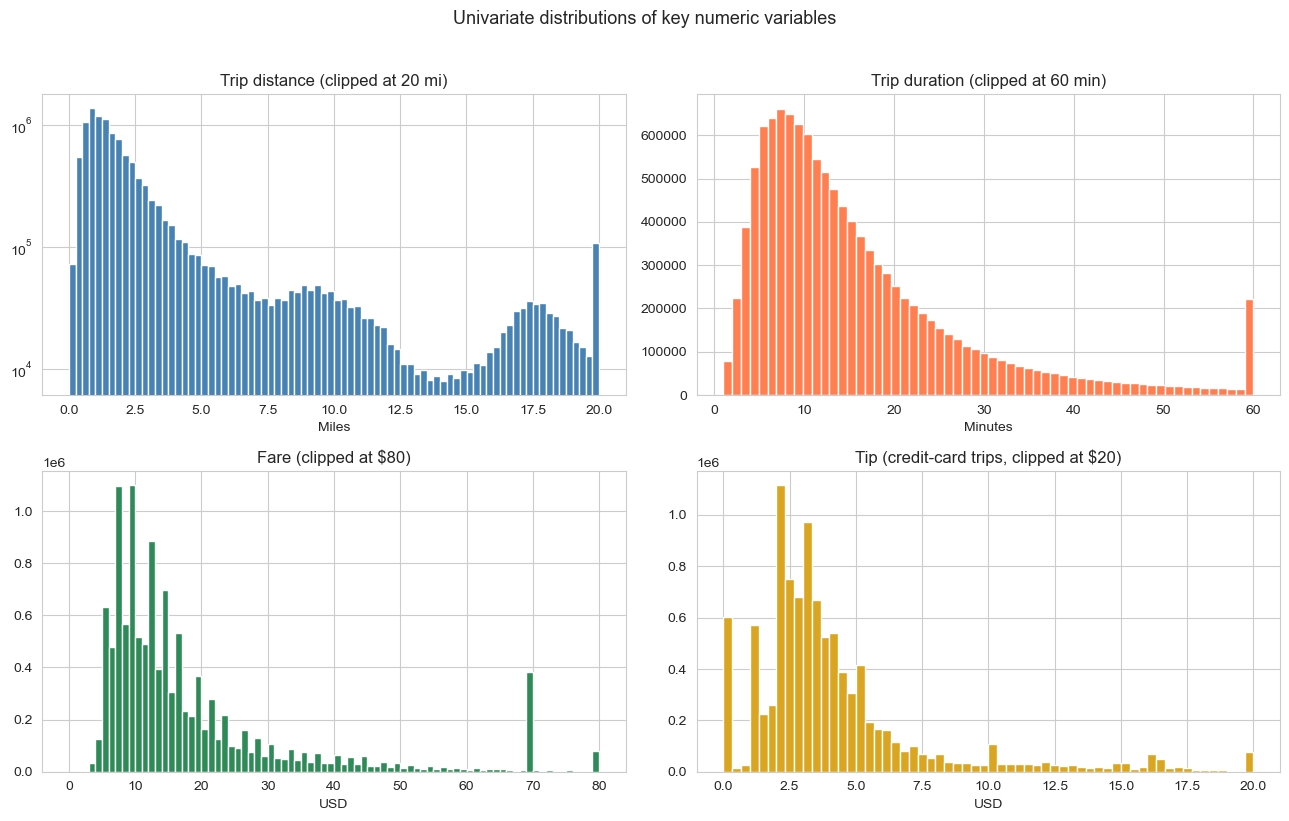

In [8]:
# 2.1 Distribution of key numeric variables
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Clip only for display so extreme values do not dominate the histogram.
axes[0, 0].hist(df['trip_distance'].clip(upper=20), bins=80, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Trip distance (clipped at 20 mi)')
axes[0, 0].set_xlabel('Miles')
axes[0, 0].set_yscale('log')

axes[0, 1].hist(df['duration_minutes'].clip(upper=60), bins=60, color='coral', edgecolor='white')
axes[0, 1].set_title('Trip duration (clipped at 60 min)')
axes[0, 1].set_xlabel('Minutes')

axes[1, 0].hist(df['fare_amount'].clip(upper=80), bins=80, color='seagreen', edgecolor='white')
axes[1, 0].set_title('Fare (clipped at $80)')
axes[1, 0].set_xlabel('USD')

# Credit-card tips are observed more reliably than cash tips.
card_tips = df.loc[df['payment_type'] == 1, 'tip_amount'].clip(upper=20)
axes[1, 1].hist(card_tips, bins=60, color='goldenrod', edgecolor='white')
axes[1, 1].set_title('Tip (credit-card trips, clipped at $20)')
axes[1, 1].set_xlabel('USD')

plt.suptitle('Univariate distributions of key numeric variables', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '2_1_univariate.png')
plt.show()

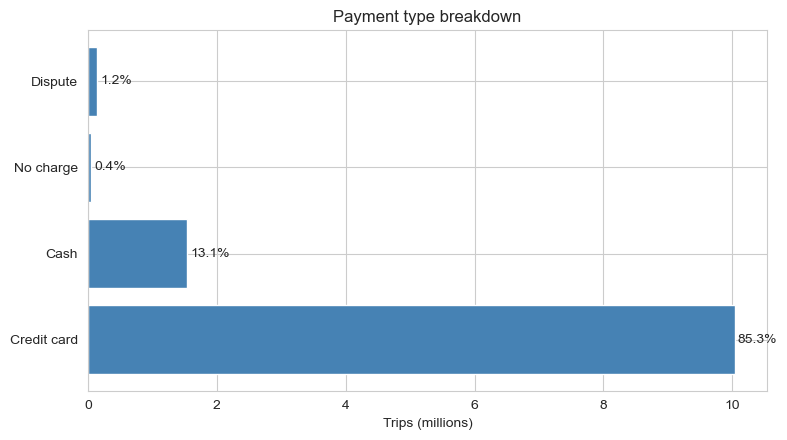

In [9]:
# 2.2 Payment type breakdown
# Translate TLC payment codes into readable labels.
pt_labels = {1: 'Credit card', 2: 'Cash', 3: 'No charge', 4: 'Dispute'}
pt_counts = df['payment_type'].value_counts().sort_index()
pt_counts.index = pt_counts.index.map(lambda x: pt_labels.get(x, f'Type {x}'))

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(pt_counts.index, pt_counts.values / 1e6, color='steelblue')
ax.set_xlabel('Trips (millions)')
ax.set_title('Payment type breakdown')
for bar, val in zip(bars, pt_counts.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val/len(df):.1%}', va='center')
plt.tight_layout()
plt.savefig(FIG_DIR / '2_2_payment_type.png')
plt.show()

## Section 3: Temporal patterns (overall + per-borough)

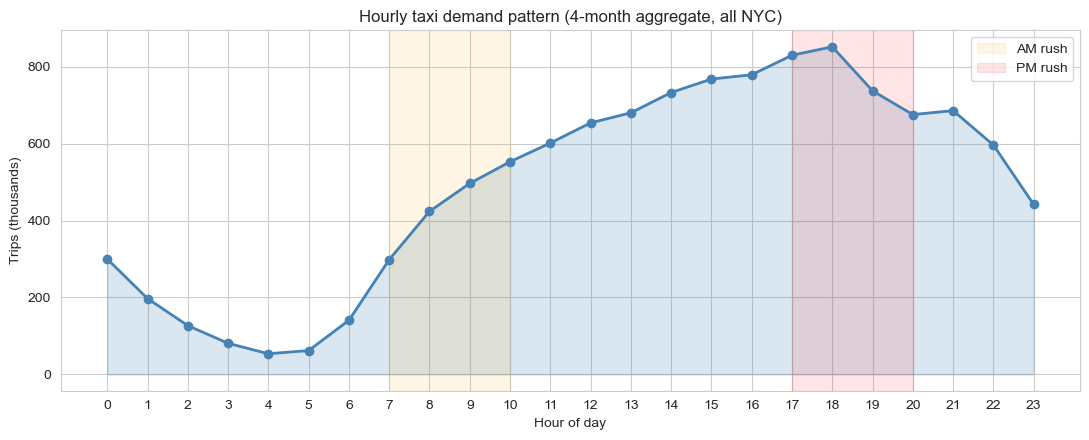

In [10]:
# 3.1 Overall hourly demand
# Count trips by hour to show the daily demand cycle.
hourly = df['pickup_hour'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(hourly.index, hourly.values / 1e3, marker='o', color='steelblue', linewidth=2)
ax.fill_between(hourly.index, hourly.values / 1e3, alpha=0.2, color='steelblue')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Trips (thousands)')
ax.set_title('Hourly taxi demand pattern (4-month aggregate, all NYC)')
ax.set_xticks(range(0, 24))
ax.axvspan(7, 10, alpha=0.1, color='orange', label='AM rush')
ax.axvspan(17, 20, alpha=0.1, color='red', label='PM rush')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '3_1_hourly_overall.png')
plt.show()

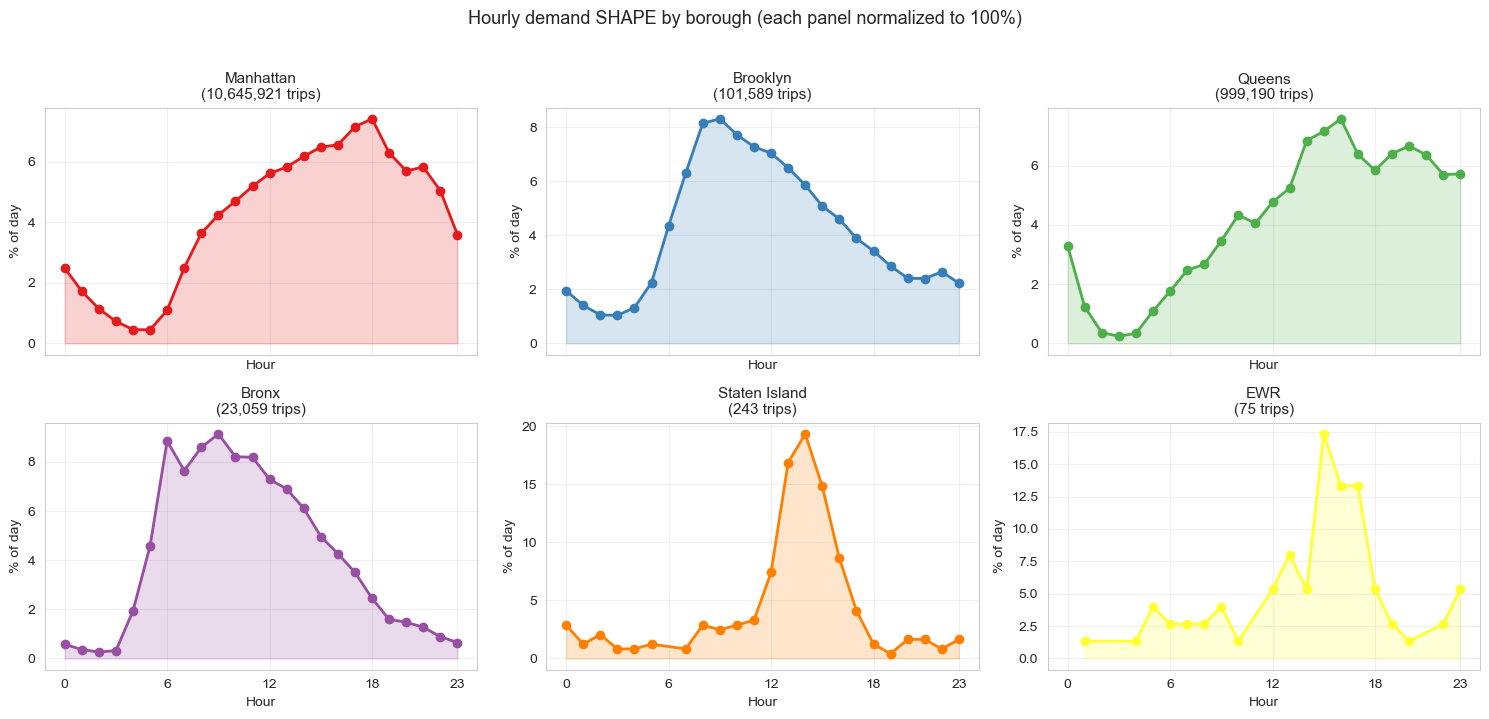


KEY FINDING: Different boroughs have meaningfully different demand shapes.


In [11]:
# 3.2 Per-borough hourly SHAPE (normalized so each panel sums to 100%)
boroughs_present = [b for b in BOROUGH_ORDER if b in df['PUBorough'].unique()]

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
axes = axes.flatten()

for i, borough in enumerate(boroughs_present):
    sub = df[df['PUBorough'] == borough]
    hr = sub['pickup_hour'].value_counts().sort_index()
    # Normalize within each borough so shapes are comparable.
    hr_pct = hr / hr.sum() * 100
    axes[i].plot(hr_pct.index, hr_pct.values, 'o-',
                  color=BOROUGH_COLORS[borough], linewidth=2)
    axes[i].fill_between(hr_pct.index, hr_pct.values, alpha=0.2,
                          color=BOROUGH_COLORS[borough])
    axes[i].set_title(f'{borough}\n({len(sub):,} trips)', fontsize=11)
    axes[i].set_xlabel('Hour')
    axes[i].set_ylabel('% of day')
    axes[i].set_xticks([0, 6, 12, 18, 23])
    axes[i].grid(True, alpha=0.3)

for j in range(len(boroughs_present), len(axes)):
    axes[j].axis('off')

plt.suptitle('Hourly demand SHAPE by borough (each panel normalized to 100%)',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '3_2_hourly_by_borough.png')
plt.show()

print('\nKEY FINDING: Different boroughs have meaningfully different demand shapes.')

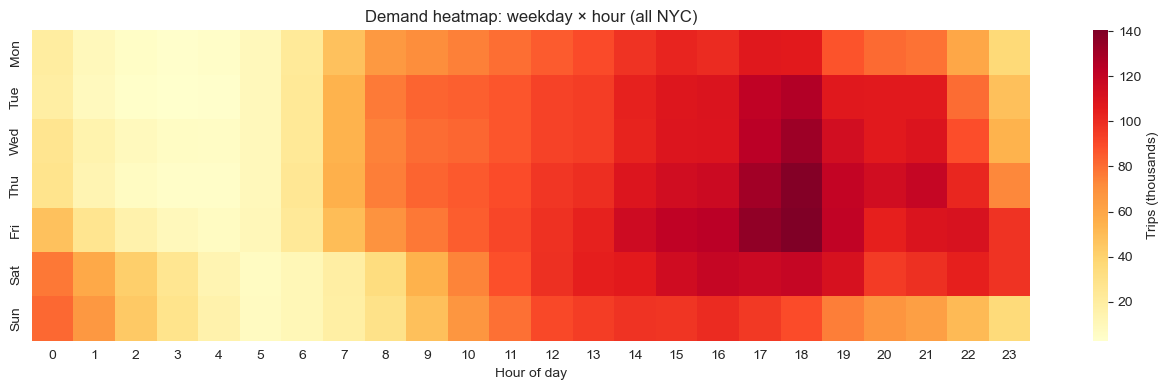

In [12]:
# 3.3 Weekday × hour heatmap (overall)
# This matrix shows recurring weekday-hour demand patterns.
pivot = df.groupby(['pickup_dayofweek', 'pickup_hour']).size().unstack()
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot.index = day_labels

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot / 1e3, cmap='YlOrRd', cbar_kws={'label': 'Trips (thousands)'}, ax=ax)
ax.set_title('Demand heatmap: weekday × hour (all NYC)')
ax.set_xlabel('Hour of day')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIG_DIR / '3_3_heatmap.png')
plt.show()

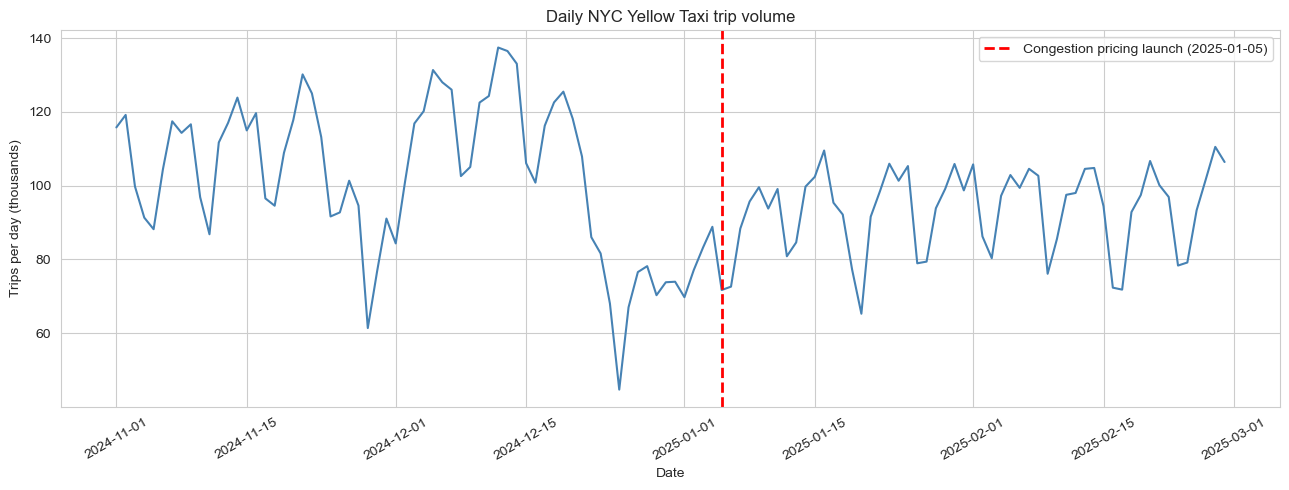

In [13]:
# 3.4 Daily volume timeline (overall)
# Daily totals make the policy launch date easy to compare.
daily = df.groupby('pickup_date').size().reset_index(name='trips')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily['pickup_date'], daily['trips'] / 1e3, color='steelblue', linewidth=1.5)
# Mark the policy start date on the timeline.
ax.axvline(POLICY_DATE, color='red', linestyle='--', linewidth=2,
           label='Congestion pricing launch (2025-01-05)')
ax.set_xlabel('Date')
ax.set_ylabel('Trips per day (thousands)')
ax.set_title('Daily NYC Yellow Taxi trip volume')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / '3_4_daily_volume.png')
plt.show()

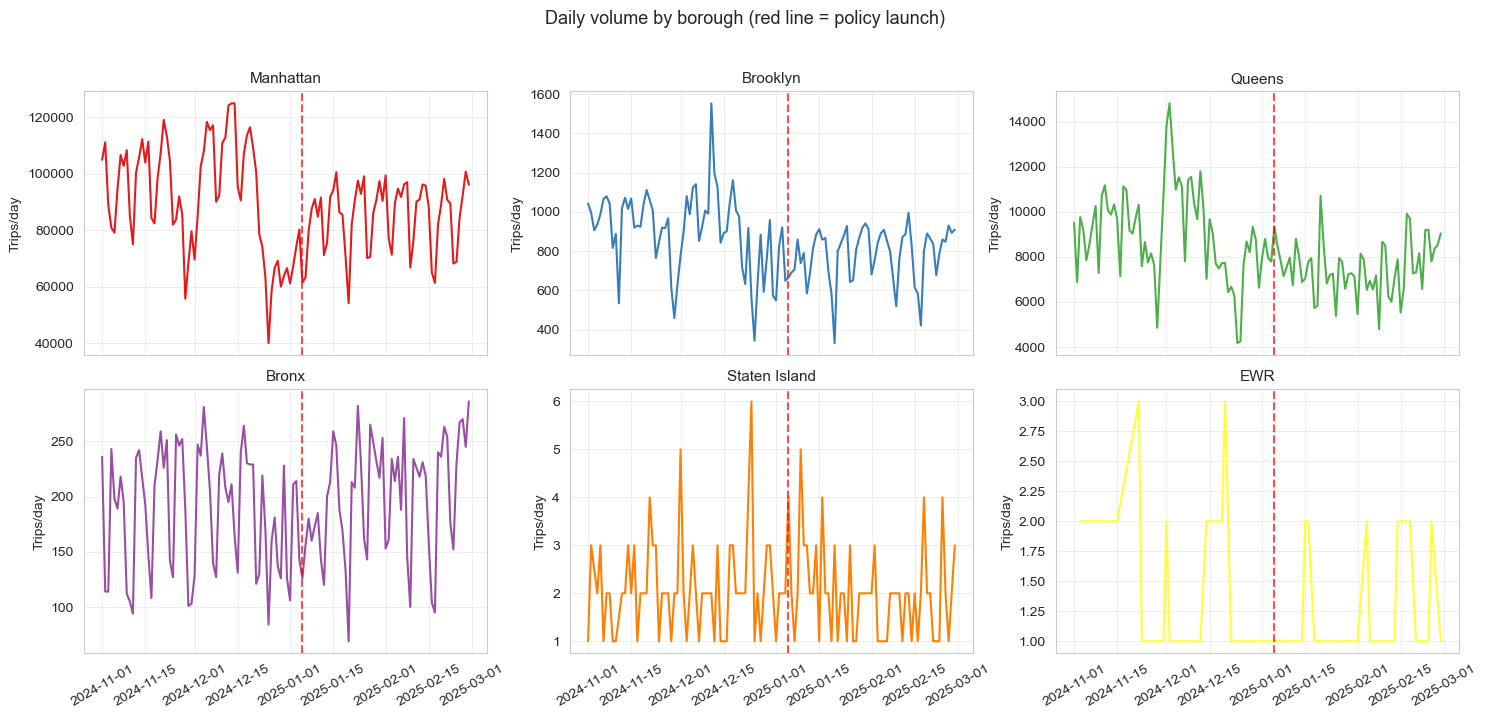

In [14]:
# 3.5 Daily volume PER BOROUGH — small multiples
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
axes = axes.flatten()

for i, borough in enumerate(boroughs_present):
    sub = df[df['PUBorough'] == borough]
    daily_b = sub.groupby('pickup_date').size().reset_index(name='trips')
    ax = axes[i]
    ax.plot(daily_b['pickup_date'], daily_b['trips'],
            color=BOROUGH_COLORS[borough], linewidth=1.5)
    # Mark the policy start date on the timeline.
    ax.axvline(POLICY_DATE, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.set_title(borough, fontsize=11)
    ax.set_ylabel('Trips/day')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3)

for j in range(len(boroughs_present), len(axes)):
    axes[j].axis('off')

plt.suptitle('Daily volume by borough (red line = policy launch)',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '3_5_daily_by_borough.png')
plt.show()

## Section 4: Spatial patterns (5 boroughs in parallel)

**Sample size caveat.** Staten Island (~240 trips) and EWR (~75 trips) have very small sample sizes in this 4-month window. Patterns for these boroughs are shown for completeness but should be **interpreted cautiously** — they are not statistically reliable and should not be used as standalone modeling targets. Manhattan, Queens, Brooklyn, and Bronx all have sufficient samples for stable analysis.

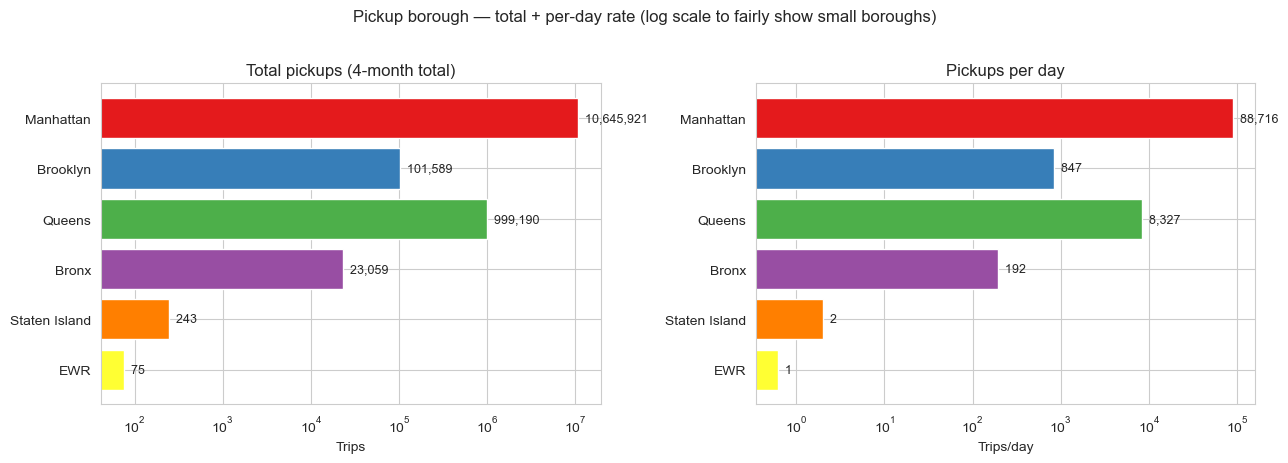

In [15]:
# 4.1 Borough breakdown — totals + per-day rate, log scale
n_days = df['pickup_date'].nunique()
pu = df['PUBorough'].value_counts()
# Per-day rates make borough comparisons fairer.
pu_perday = pu / n_days

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ordered = [b for b in BOROUGH_ORDER if b in pu.index]
axes[0].barh(ordered, [pu[b] for b in ordered],
              color=[BOROUGH_COLORS[b] for b in ordered])
axes[0].set_title('Total pickups (4-month total)')
axes[0].set_xlabel('Trips')
axes[0].invert_yaxis()
axes[0].set_xscale('log')
for i, b in enumerate(ordered):
    axes[0].text(pu[b], i, f'  {pu[b]:,}', va='center', fontsize=9)

axes[1].barh(ordered, [pu_perday[b] for b in ordered],
              color=[BOROUGH_COLORS[b] for b in ordered])
axes[1].set_title('Pickups per day')
axes[1].set_xlabel('Trips/day')
axes[1].invert_yaxis()
axes[1].set_xscale('log')
for i, b in enumerate(ordered):
    axes[1].text(pu_perday[b], i, f'  {pu_perday[b]:,.0f}', va='center', fontsize=9)

plt.suptitle('Pickup borough — total + per-day rate (log scale to fairly show small boroughs)',
             y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / '4_1_borough_breakdown.png')
plt.show()

In [16]:
# 4.2 Per-borough trip economics
stats = df.groupby('PUBorough', observed=True).agg(
    n_trips=('fare_amount', 'count'),
    avg_fare=('fare_amount', 'mean'),
    avg_distance=('trip_distance', 'mean'),
    avg_duration=('duration_minutes', 'mean'),
    avg_speed=('avg_speed_mph', 'mean'),
).round(2)
stats = stats.reindex([b for b in BOROUGH_ORDER if b in stats.index])
print('Per-borough trip economics:')
print(stats)

Per-borough trip economics:
                n_trips   avg_fare  avg_distance  avg_duration  avg_speed
PUBorough                                                                
Manhattan      10645921  15.250000          2.26     14.010000   9.460000
Brooklyn         101589  28.309999          5.92     35.540001  10.570000
Queens           999190  52.910000         12.65     37.560001  22.219999
Bronx             23059  36.470001          9.45     48.959999  12.460000
Staten Island       243  11.280000          7.41     17.950001  30.639999
EWR                  75  78.480003         10.10     27.920000  20.240000


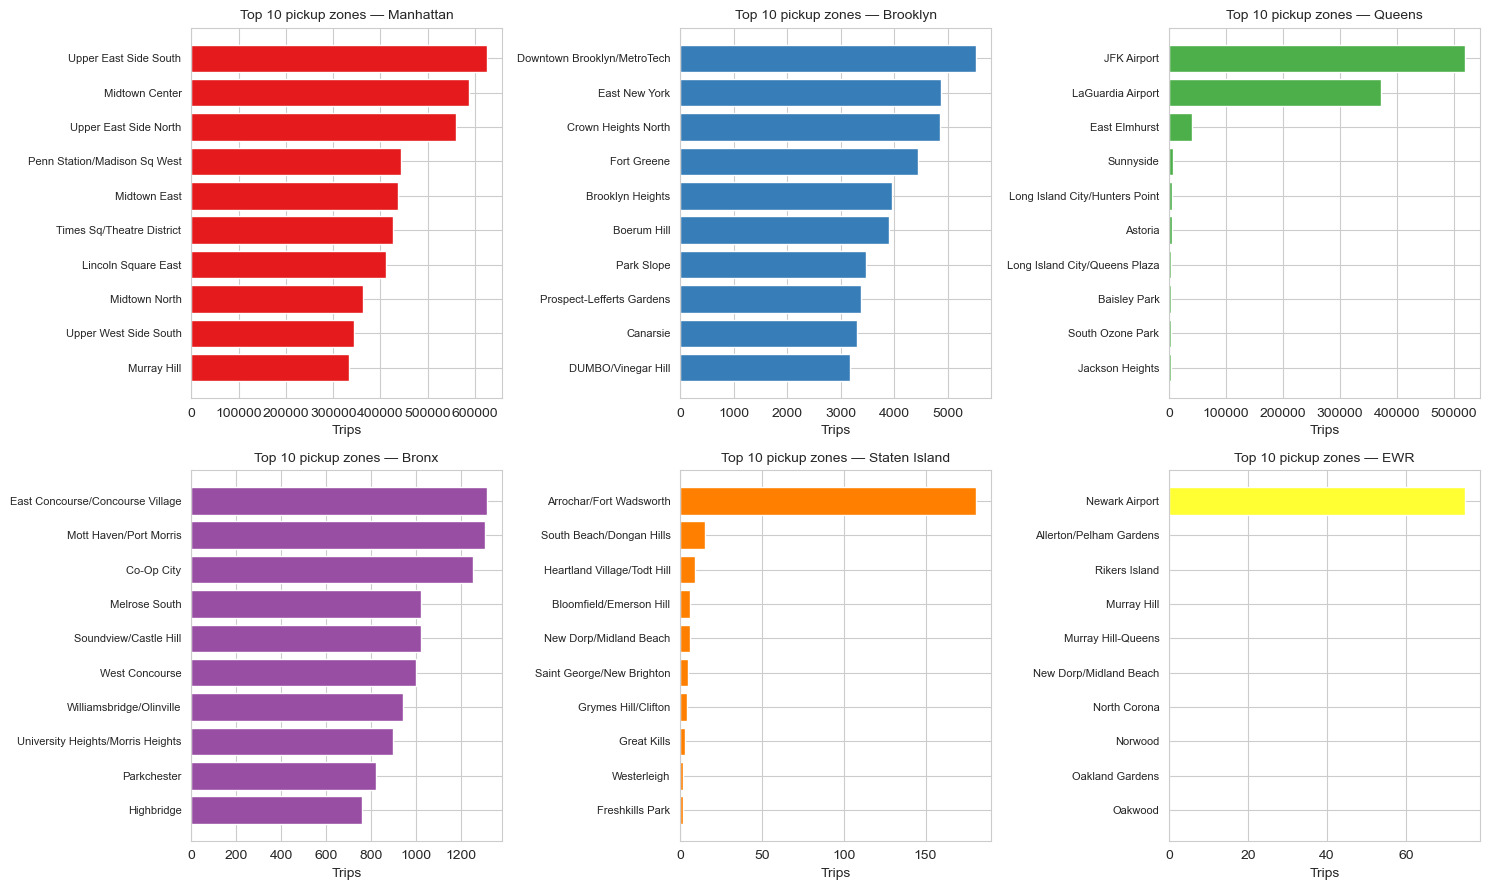

In [17]:
# 4.3 Top 10 pickup zones in each borough
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, borough in enumerate(boroughs_present):
    sub = df[df['PUBorough'] == borough]
    top = sub['PUZone'].value_counts().head(10)
    ax = axes[i]
    ax.barh(top.index[::-1], top.values[::-1],
            color=BOROUGH_COLORS[borough])
    ax.set_title(f'Top 10 pickup zones — {borough}', fontsize=10)
    ax.set_xlabel('Trips')
    ax.tick_params(axis='y', labelsize=8)

for j in range(len(boroughs_present), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(FIG_DIR / '4_3_top_zones_by_borough.png')
plt.show()

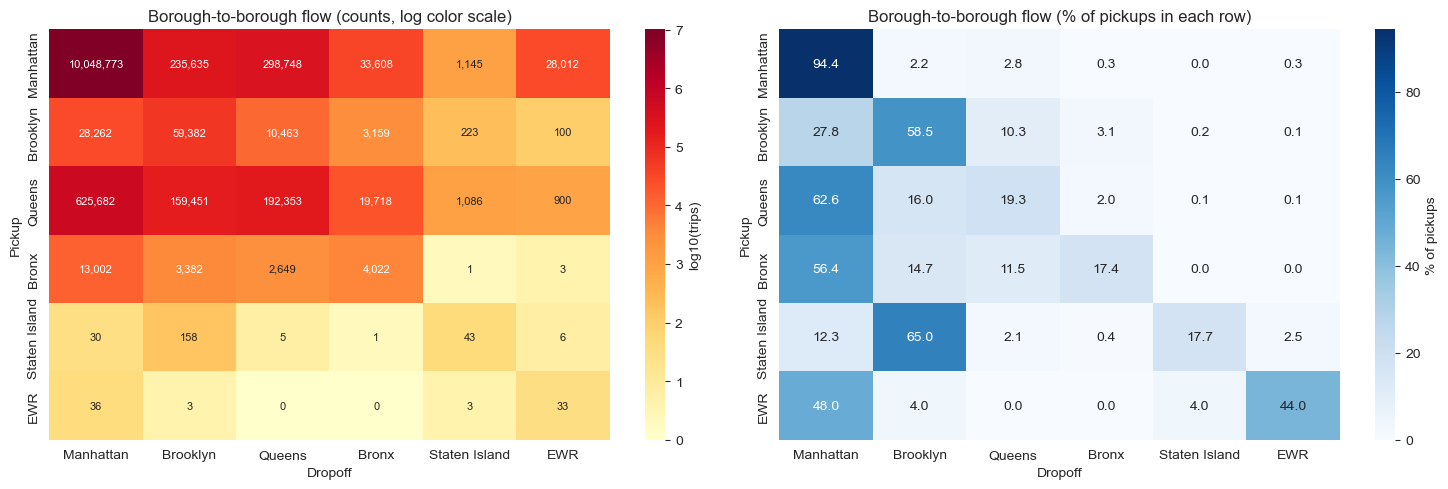


KEY FINDING: Each borough has a distinct destination pattern.


In [18]:
# 4.4 Borough-to-borough flow matrix (two views)
flow = df.groupby(['PUBorough', 'DOBorough'], observed=True).size().unstack(fill_value=0)
flow = flow.reindex(
    index=[b for b in BOROUGH_ORDER if b in flow.index],
    columns=[b for b in BOROUGH_ORDER if b in flow.columns],
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(np.log10(flow + 1), cmap='YlOrRd', annot=flow.values,
             fmt=',d', cbar_kws={'label': 'log10(trips)'}, ax=axes[0],
             annot_kws={'size': 8})
axes[0].set_title('Borough-to-borough flow (counts, log color scale)')
axes[0].set_xlabel('Dropoff')
axes[0].set_ylabel('Pickup')

# Convert flows to row percentages to show destination mix.
flow_pct = flow.div(flow.sum(axis=1), axis=0) * 100
sns.heatmap(flow_pct, cmap='Blues', annot=True, fmt='.1f',
             cbar_kws={'label': '% of pickups'}, ax=axes[1])
axes[1].set_title('Borough-to-borough flow (% of pickups in each row)')
axes[1].set_xlabel('Dropoff')
axes[1].set_ylabel('Pickup')

plt.tight_layout()
plt.savefig(FIG_DIR / '4_4_borough_flow.png')
plt.show()

print('\nKEY FINDING: Each borough has a distinct destination pattern.')

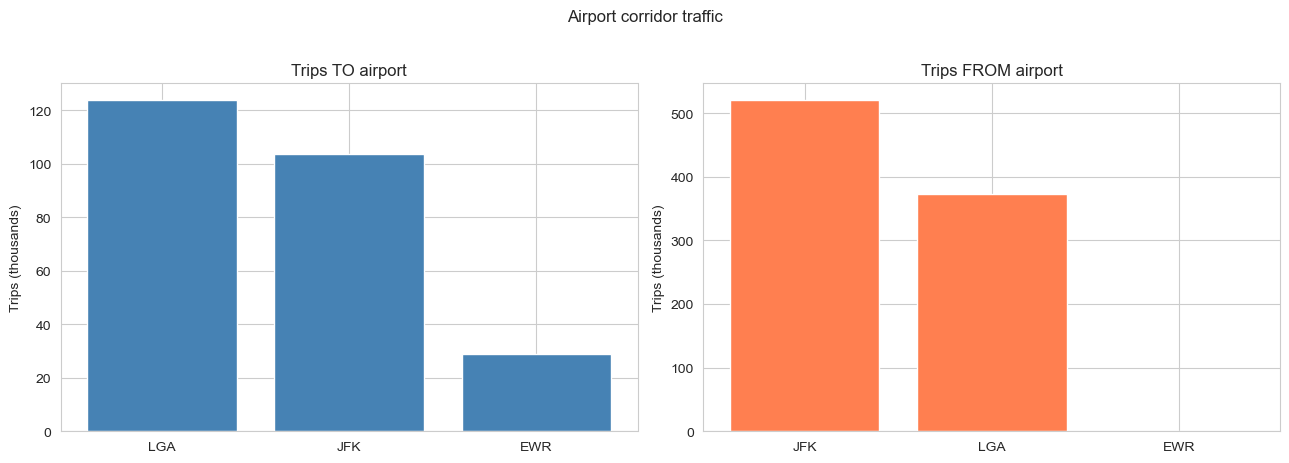

In [19]:
# 4.5 Airport corridors
# TLC airport zone IDs for JFK, LGA, and EWR.
AIRPORT_IDS = {132: 'JFK', 138: 'LGA', 1: 'EWR'}
to_airport = df[df['DOLocationID'].isin(AIRPORT_IDS.keys())].copy()
to_airport['airport'] = to_airport['DOLocationID'].map(AIRPORT_IDS)
from_airport = df[df['PULocationID'].isin(AIRPORT_IDS.keys())].copy()
from_airport['airport'] = from_airport['PULocationID'].map(AIRPORT_IDS)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
to_counts = to_airport['airport'].value_counts()
from_counts = from_airport['airport'].value_counts()

axes[0].bar(to_counts.index, to_counts.values / 1e3, color='steelblue')
axes[0].set_title('Trips TO airport')
axes[0].set_ylabel('Trips (thousands)')

axes[1].bar(from_counts.index, from_counts.values / 1e3, color='coral')
axes[1].set_title('Trips FROM airport')
axes[1].set_ylabel('Trips (thousands)')

plt.suptitle('Airport corridor traffic', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / '4_5_airport_traffic.png')
plt.show()

## Section 5: Weather effects

In [20]:
# Build weather categories (snow_mm is all null, derive from temp + precip)
# Approximate snow using cold temperature plus precipitation.
df['is_snowing'] = (df['temp_c'] <= 0) & (df['precip_mm'] > 0.1)

# Group precipitation into readable weather categories.
df['weather_category'] = pd.cut(
    df['precip_mm'].fillna(0),
    bins=[-0.01, 0.1, 2.5, 7.5, 100],
    labels=['Dry', 'Light rain', 'Moderate rain', 'Heavy rain'],
)

# Add 'Snow' to the category list BEFORE assigning it
df['weather_category'] = df['weather_category'].cat.add_categories(['Snow'])
df.loc[df['is_snowing'], 'weather_category'] = 'Snow'

weather_dist = df['weather_category'].value_counts()
print('Weather category distribution:')
print(weather_dist)

Weather category distribution:
weather_category
Dry              10564309
Light rain         977600
Snow               169171
Moderate rain       58997
Heavy rain              0
Name: count, dtype: int64


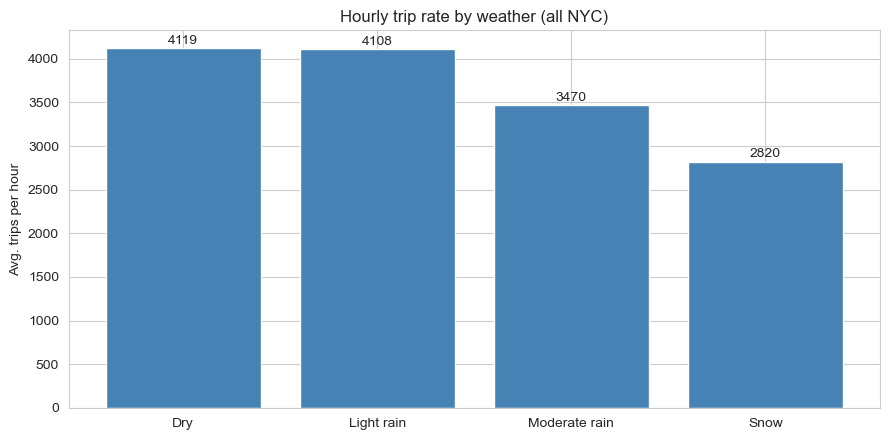

In [21]:
# 5.1 Trips per hour by weather (overall)
# Count available weather hours for weather-normalized demand rates.
weather_hours = df.drop_duplicates('pickup_hour_ts').groupby('weather_category', observed=True).size()
trips_per_weather = df.groupby('weather_category', observed=True).size()
trips_per_hour = trips_per_weather / weather_hours

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(trips_per_hour.index.astype(str), trips_per_hour.values, color='steelblue')
ax.set_ylabel('Avg. trips per hour')
ax.set_title('Hourly trip rate by weather (all NYC)')
for i, v in enumerate(trips_per_hour.values):
    ax.text(i, v + 50, f'{v:.0f}', ha='center')
plt.tight_layout()
plt.savefig(FIG_DIR / '5_1_weather_demand.png')
plt.show()

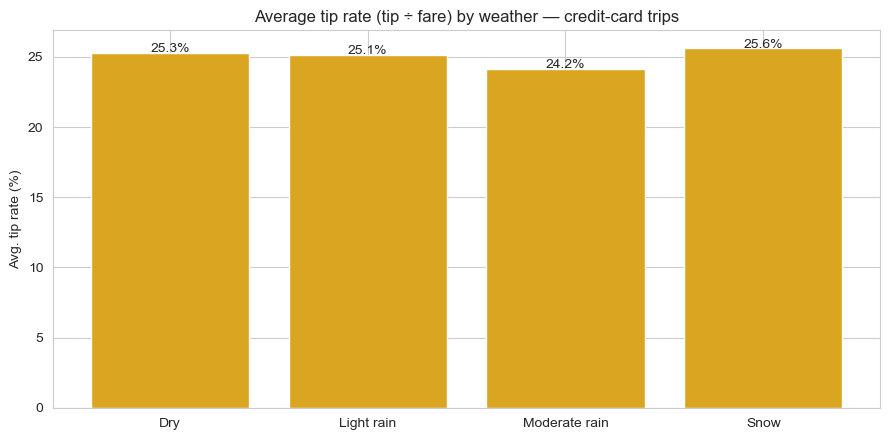

In [22]:
# 5.2 Tip rate by weather
# Build tip features only on credit-card trips.
card = df[df['payment_type'] == 1].copy()
card['tip_pct'] = (card['tip_amount'] / card['fare_amount']).clip(0, 1)
tip_by_weather = card.groupby('weather_category', observed=True)['tip_pct'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(tip_by_weather.index.astype(str), tip_by_weather.values, color='goldenrod')
ax.set_ylabel('Avg. tip rate (%)')
ax.set_title('Average tip rate (tip ÷ fare) by weather — credit-card trips')
for i, v in enumerate(tip_by_weather.values):
    ax.text(i, v + 0.05, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.savefig(FIG_DIR / '5_2_tip_by_weather.png')
plt.show()

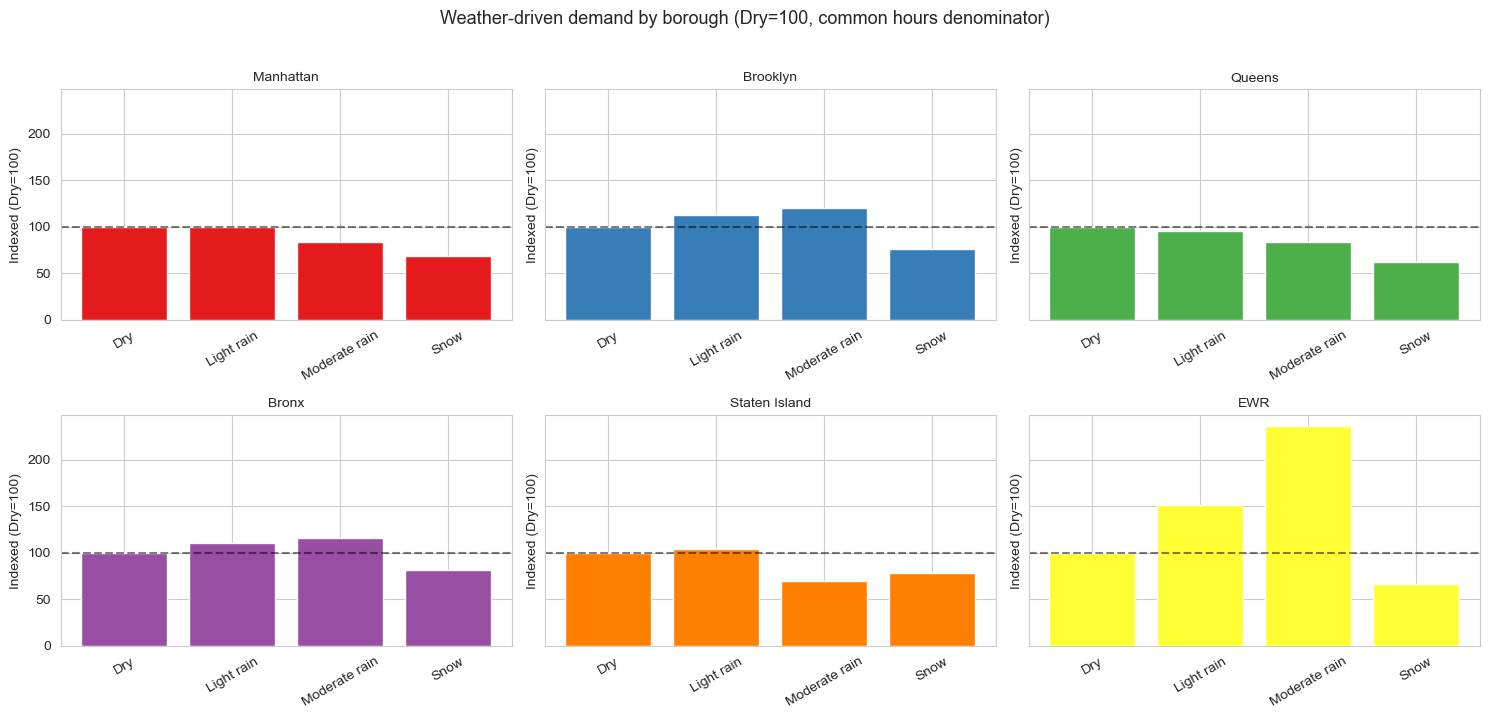

In [23]:
# 5.3 Per-borough weather demand response (indexed to Dry=100)
# Use the SAME weather-hours denominator across all boroughs so that
# small-sample boroughs (Staten Island, EWR) are not unfairly inflated.
common_weather_hours = (
    df.drop_duplicates('pickup_hour_ts')
      .groupby('weather_category', observed=True)
      .size()
)

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
axes = axes.flatten()

for i, borough in enumerate(boroughs_present):
    sub = df[df['PUBorough'] == borough]
    sub_per_hr = sub.groupby('weather_category', observed=True).size() / common_weather_hours
    if 'Dry' in sub_per_hr.index and sub_per_hr['Dry'] > 0:
        sub_norm = sub_per_hr / sub_per_hr['Dry'] * 100
    else:
        sub_norm = sub_per_hr / sub_per_hr.iloc[0] * 100
    sub_norm = sub_norm.dropna()
    axes[i].bar(sub_norm.index.astype(str), sub_norm.values,
                color=BOROUGH_COLORS[borough])
    axes[i].axhline(100, color='black', linestyle='--', alpha=0.5)
    axes[i].set_title(f'{borough}', fontsize=10)
    axes[i].set_ylabel('Indexed (Dry=100)')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(len(boroughs_present), len(axes)):
    axes[j].axis('off')

plt.suptitle('Weather-driven demand by borough (Dry=100, common hours denominator)',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '5_3_weather_by_borough.png')
plt.show()

## Section 6: Patterns around the congestion pricing launch

This section provides a **descriptive comparison** of trip activity before and after the January 5, 2025 congestion pricing launch. Differences shown below are **associations, not causal estimates** — formal causal identification (with proper treatment/control assignment, parallel-trends testing, and standard errors) is reserved for the Plan B DID analysis in a separate notebook.

In [24]:
pre = df[~df['post_congestion_fee']]
post = df[df['post_congestion_fee']]
n_pre_days = pre['pickup_date'].nunique()
n_post_days = post['pickup_date'].nunique()

summary = pd.DataFrame({
    'Pre-policy': [
        len(pre), n_pre_days, len(pre) / n_pre_days,
        pre['fare_amount'].mean(), pre['trip_distance'].mean(),
        pre['duration_minutes'].mean(), pre['avg_speed_mph'].mean(),
        pre.loc[pre['payment_type']==1, 'tip_amount'].mean(),
    ],
    'Post-policy': [
        len(post), n_post_days, len(post) / n_post_days,
        post['fare_amount'].mean(), post['trip_distance'].mean(),
        post['duration_minutes'].mean(), post['avg_speed_mph'].mean(),
        post.loc[post['payment_type']==1, 'tip_amount'].mean(),
    ],
}, index=['Total trips', 'Days', 'Trips/day', 'Avg fare ($)',
         'Avg distance (mi)', 'Avg duration (min)', 'Avg speed (mph)',
         'Avg tip ($, card)']).round(2)
summary['% change'] = ((summary['Post-policy'] / summary['Pre-policy'] - 1) * 100).round(1)
print(summary)

                    Pre-policy  Post-policy  % change
Total trips         6637380.00   5132697.00     -22.7
Days                     65.00        55.00     -15.4
Trips/day            102113.54     93321.76      -8.6
Avg fare ($)             19.50        17.44     -10.6
Avg distance (mi)         3.27         3.07      -6.1
Avg duration (min)       17.49        14.67     -16.1
Avg speed (mph)          10.22        10.99       7.5
Avg tip ($, card)         4.34         4.02      -7.4


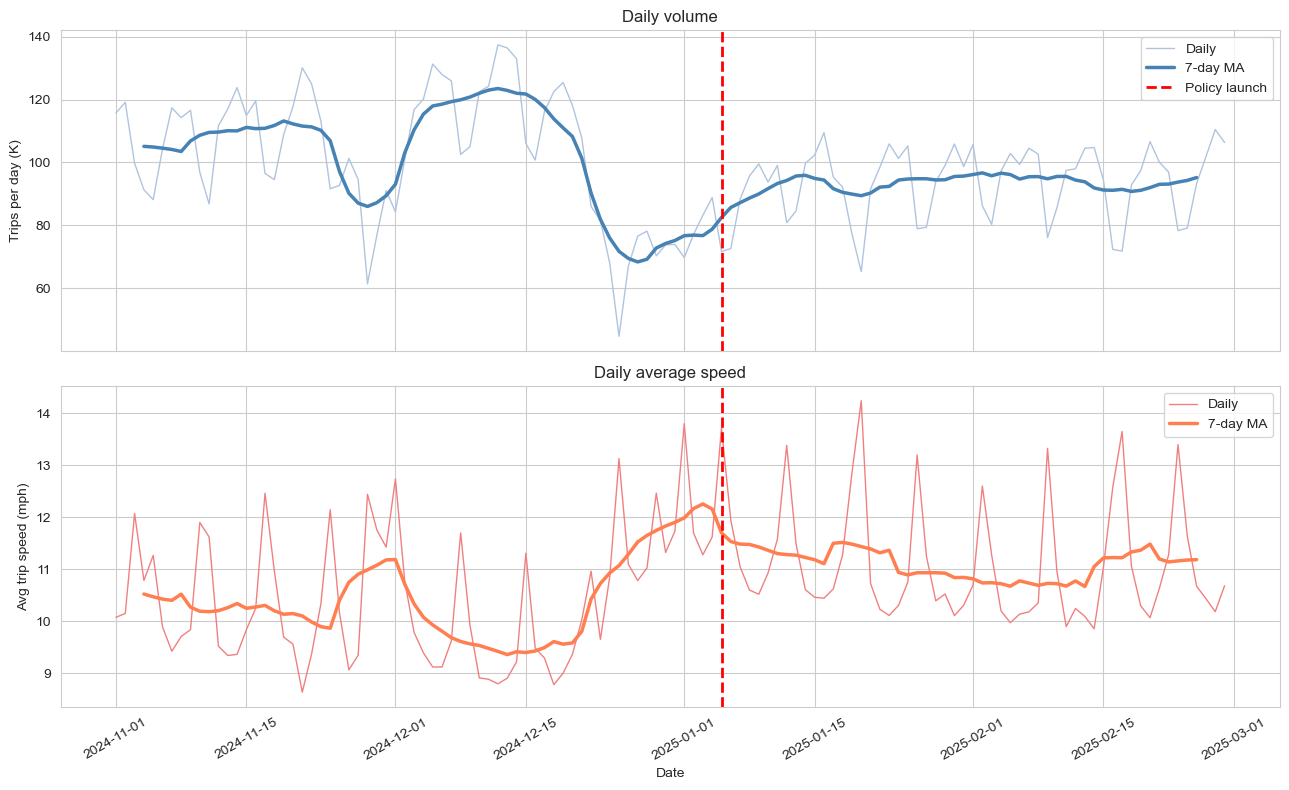

In [25]:
# 6.1 Daily volume + speed timeline with policy line
daily_full = df.groupby('pickup_date').agg(
    trips=('fare_amount', 'count'),
    avg_speed=('avg_speed_mph', 'mean'),
).reset_index()
daily_full['trips_ma7'] = daily_full['trips'].rolling(7, center=True).mean()
daily_full['speed_ma7'] = daily_full['avg_speed'].rolling(7, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(daily_full['pickup_date'], daily_full['trips'] / 1e3,
              color='lightsteelblue', linewidth=1, label='Daily')
axes[0].plot(daily_full['pickup_date'], daily_full['trips_ma7'] / 1e3,
              color='steelblue', linewidth=2.5, label='7-day MA')
axes[0].axvline(POLICY_DATE, color='red', linestyle='--', linewidth=2, label='Policy launch')
axes[0].set_ylabel('Trips per day (K)')
axes[0].set_title('Daily volume')
axes[0].legend()

axes[1].plot(daily_full['pickup_date'], daily_full['avg_speed'],
              color='lightcoral', linewidth=1, label='Daily')
axes[1].plot(daily_full['pickup_date'], daily_full['speed_ma7'],
              color='coral', linewidth=2.5, label='7-day MA')
axes[1].axvline(POLICY_DATE, color='red', linestyle='--', linewidth=2)
axes[1].set_ylabel('Avg trip speed (mph)')
axes[1].set_title('Daily average speed')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / '6_1_daily_with_policy.png')
plt.show()

### Defining "CBD-affected" zones for descriptive comparison

CBD-affected pickup zones are **empirically** defined here as zones where more than 50% of post-policy trips include a positive CBD congestion fee. This empirical proxy is used for descriptive EDA only, and may not exactly match the official MTA congestion zone boundary (Manhattan south of 60th Street). The Plan B DID analysis will use the **official boundary** for treatment assignment to avoid circular reasoning.

In [26]:
# 6.2 Identify CBD-affected zones (treatment) using post-policy fee rate
zone_post_fee_rate = post.groupby('PULocationID', observed=True).apply(
    lambda x: (x['cbd_congestion_fee'] > 0).mean()
)
cbd_zones = set(zone_post_fee_rate[zone_post_fee_rate > 0.5].index)
non_cbd_zones = set(zone_post_fee_rate[zone_post_fee_rate <= 0.5].index)
print(f'CBD-affected zones (treatment): {len(cbd_zones)}')
print(f'Non-CBD zones (control): {len(non_cbd_zones)}')

df['zone_class'] = df['PULocationID'].apply(
    lambda x: 'CBD pickup' if x in cbd_zones else 'Non-CBD pickup'
)

CBD-affected zones (treatment): 44
Non-CBD zones (control): 206


In [27]:
# 6.3 DID-style descriptive comparison: pre/post × CBD/non-CBD
by_class = df.groupby(['post_congestion_fee', 'zone_class'], observed=True).agg(
    trips=('fare_amount', 'count'),
    days=('pickup_date', 'nunique'),
    avg_speed=('avg_speed_mph', 'mean'),
    avg_fare=('fare_amount', 'mean'),
).reset_index()
by_class['trips_per_day'] = by_class['trips'] / by_class['days']

# Pivot makes pre/post percent changes easy to compare.
pivot_class = by_class.pivot(index='zone_class', columns='post_congestion_fee', values='trips_per_day')
pivot_class.columns = ['Pre-policy', 'Post-policy']
pivot_class['% change'] = ((pivot_class['Post-policy'] / pivot_class['Pre-policy'] - 1) * 100).round(1)
print('Trips per day:')
print(pivot_class)

if 'CBD pickup' in pivot_class.index and 'Non-CBD pickup' in pivot_class.index:
    did = pivot_class.loc['CBD pickup', '% change'] - pivot_class.loc['Non-CBD pickup', '% change']
    print(f'\nDID-style estimate (treatment − control): {did:+.1f} percentage points')
    print('(Descriptive only — proper DID via panel regression in Plan B.)')

Trips per day:
                  Pre-policy   Post-policy  % change
zone_class                                          
CBD pickup      69049.000000  62751.363636      -9.1
Non-CBD pickup  33064.538462  30570.400000      -7.5

DID-style estimate (treatment − control): -1.6 percentage points
(Descriptive only — proper DID via panel regression in Plan B.)


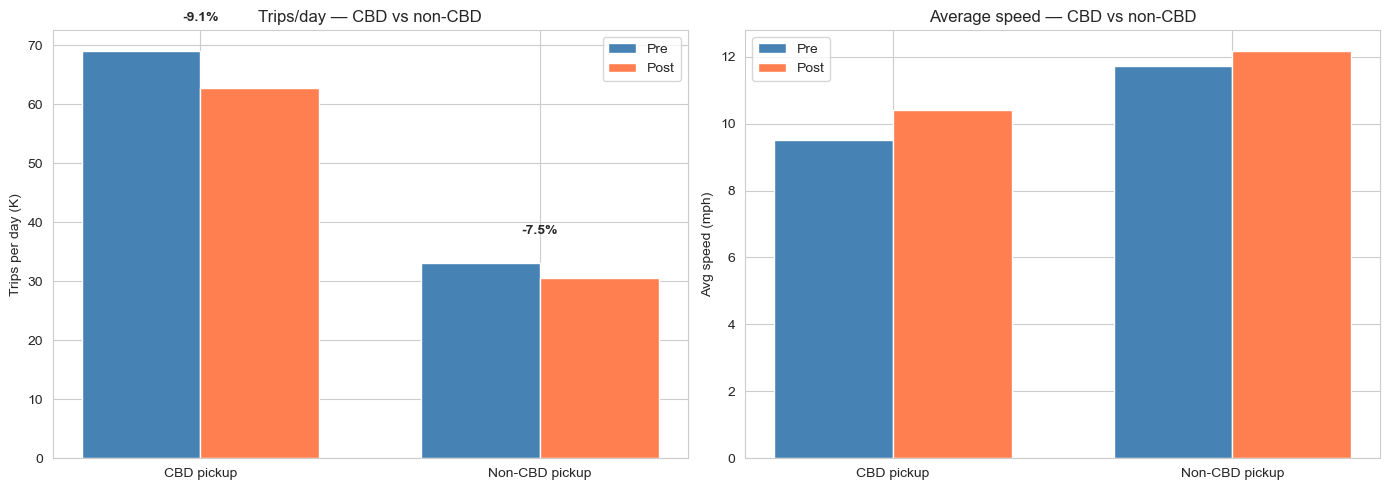

In [28]:
# 6.4 DID visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(pivot_class))
width = 0.35
axes[0].bar(x - width/2, pivot_class['Pre-policy'] / 1e3, width,
             label='Pre', color='steelblue')
axes[0].bar(x + width/2, pivot_class['Post-policy'] / 1e3, width,
             label='Post', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(pivot_class.index)
axes[0].set_ylabel('Trips per day (K)')
axes[0].set_title('Trips/day — CBD vs non-CBD')
axes[0].legend()
for i, (pre_v, post_v, pct) in enumerate(
    zip(pivot_class['Pre-policy'], pivot_class['Post-policy'], pivot_class['% change'])
):
    axes[0].text(i, max(pre_v, post_v) / 1e3 + 5, f'{pct:+.1f}%',
                  ha='center', fontweight='bold')

speed_pivot = by_class.pivot(index='zone_class', columns='post_congestion_fee', values='avg_speed')
speed_pivot.columns = ['Pre-policy', 'Post-policy']
axes[1].bar(x - width/2, speed_pivot['Pre-policy'], width,
             label='Pre', color='steelblue')
axes[1].bar(x + width/2, speed_pivot['Post-policy'], width,
             label='Post', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(speed_pivot.index)
axes[1].set_ylabel('Avg speed (mph)')
axes[1].set_title('Average speed — CBD vs non-CBD')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '6_4_did_comparison.png')
plt.show()

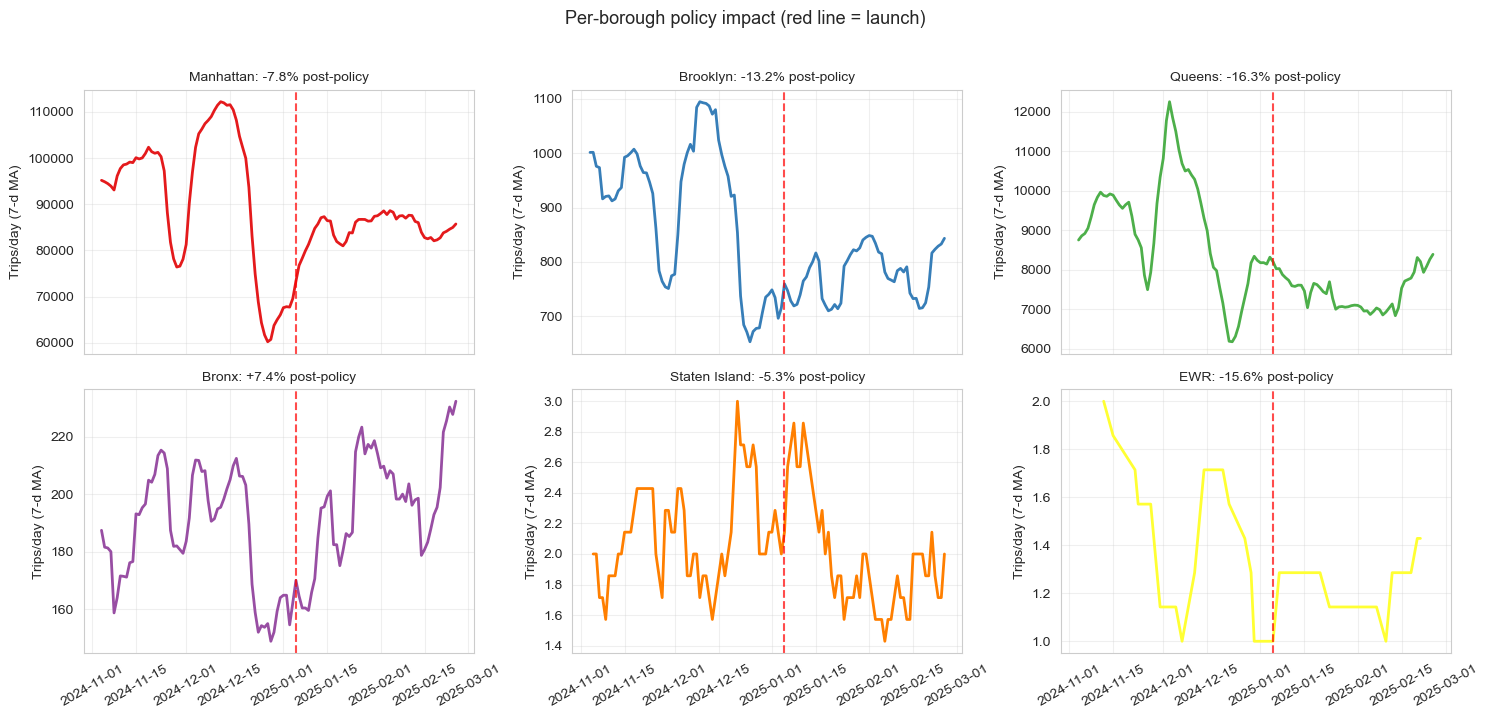

In [29]:
# 6.5 Per-borough policy impact (small multiples with % change in title)
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
axes = axes.flatten()

for i, borough in enumerate(boroughs_present):
    sub = df[df['PUBorough'] == borough]
    daily_b = sub.groupby('pickup_date').size().reset_index(name='trips')
    daily_b['trips_ma7'] = daily_b['trips'].rolling(7, center=True).mean()
    ax = axes[i]
    ax.plot(daily_b['pickup_date'], daily_b['trips_ma7'],
            color=BOROUGH_COLORS[borough], linewidth=2)
    # Mark the policy start date on the timeline.
    ax.axvline(POLICY_DATE, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    pre_avg = daily_b[daily_b['pickup_date'] < POLICY_DATE]['trips'].mean()
    post_avg = daily_b[daily_b['pickup_date'] >= POLICY_DATE]['trips'].mean()
    pct = (post_avg / pre_avg - 1) * 100 if pre_avg > 0 else 0
    ax.set_title(f'{borough}: {pct:+.1f}% post-policy', fontsize=10)
    ax.set_ylabel('Trips/day (7-d MA)')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3)

for j in range(len(boroughs_present), len(axes)):
    axes[j].axis('off')

plt.suptitle('Per-borough policy impact (red line = launch)',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '6_5_policy_by_borough.png')
plt.show()

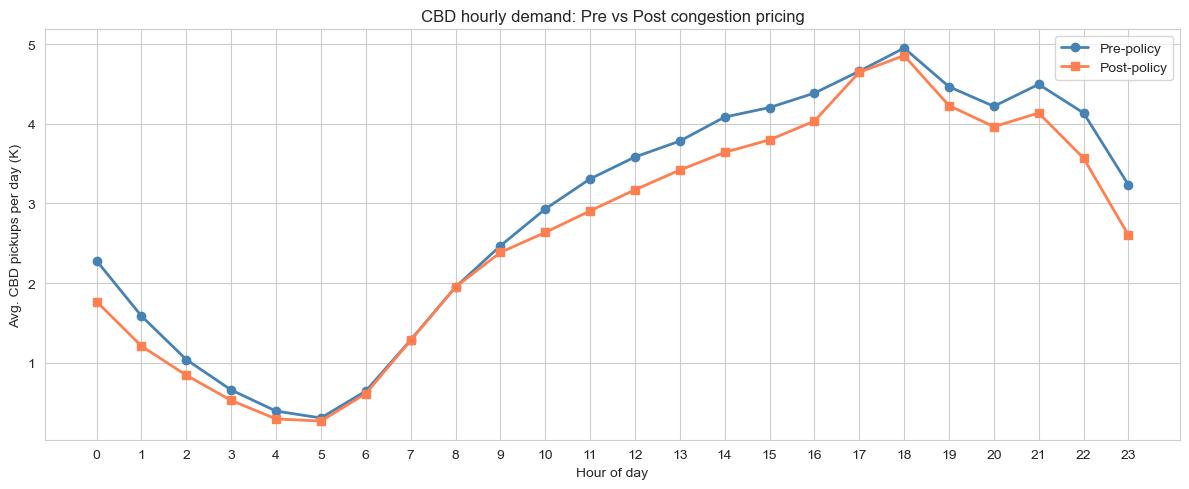

In [30]:
# 6.6 CBD hourly demand: pre vs post
df_cbd = df[df['zone_class'] == 'CBD pickup']
hourly_pre = df_cbd[~df_cbd['post_congestion_fee']].groupby('pickup_hour').size() / n_pre_days
hourly_post = df_cbd[df_cbd['post_congestion_fee']].groupby('pickup_hour').size() / n_post_days

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_pre.index, hourly_pre.values / 1e3, 'o-',
        label='Pre-policy', color='steelblue', linewidth=2)
ax.plot(hourly_post.index, hourly_post.values / 1e3, 's-',
        label='Post-policy', color='coral', linewidth=2)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Avg. CBD pickups per day (K)')
ax.set_title('CBD hourly demand: Pre vs Post congestion pricing')
ax.legend()
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig(FIG_DIR / '6_6_cbd_hourly.png')
plt.show()

## Section 7: Tip behavior

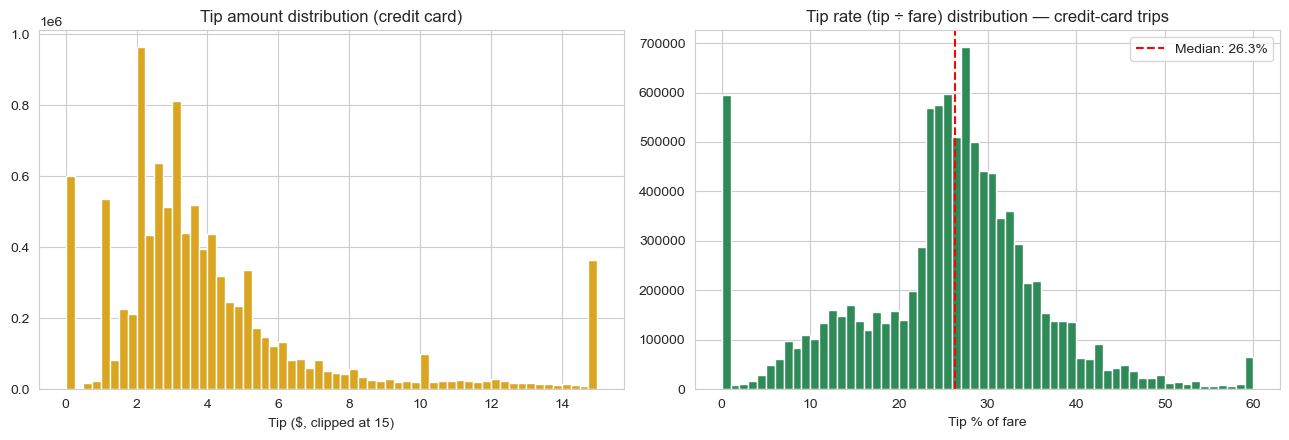

In [31]:
# Build tip features only on credit-card trips.
card = df[df['payment_type'] == 1].copy()
card = card[card['fare_amount'] > 0]
card['tip_pct'] = (card['tip_amount'] / card['fare_amount']).clip(0, 0.6)

# 7.1 Tip distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(card['tip_amount'].clip(upper=15), bins=60, color='goldenrod', edgecolor='white')
axes[0].set_xlabel('Tip ($, clipped at 15)')
axes[0].set_title('Tip amount distribution (credit card)')

axes[1].hist(card['tip_pct'] * 100, bins=60, color='seagreen', edgecolor='white')
axes[1].set_xlabel('Tip % of fare')
axes[1].axvline(card['tip_pct'].median() * 100, color='red', linestyle='--',
                label=f'Median: {card["tip_pct"].median()*100:.1f}%')
axes[1].set_title('Tip rate (tip ÷ fare) distribution — credit-card trips')
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '7_1_tip_distribution.png')
plt.show()

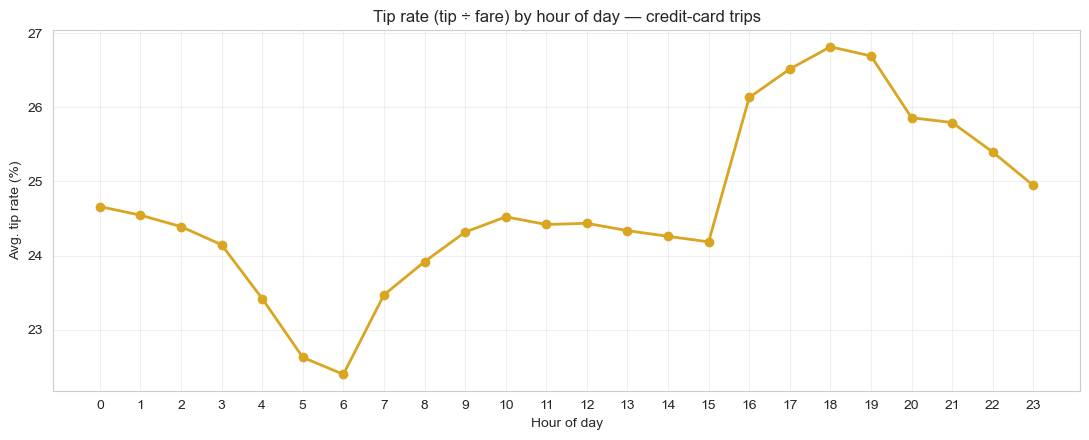

In [32]:
# 7.2 Tip rate by hour (overall)
tip_by_hour = card.groupby('pickup_hour')['tip_pct'].mean() * 100

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(tip_by_hour.index, tip_by_hour.values, 'o-', color='goldenrod', linewidth=2)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Avg. tip rate (%)')
ax.set_title('Tip rate (tip ÷ fare) by hour of day — credit-card trips')
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / '7_2_tip_by_hour.png')
plt.show()

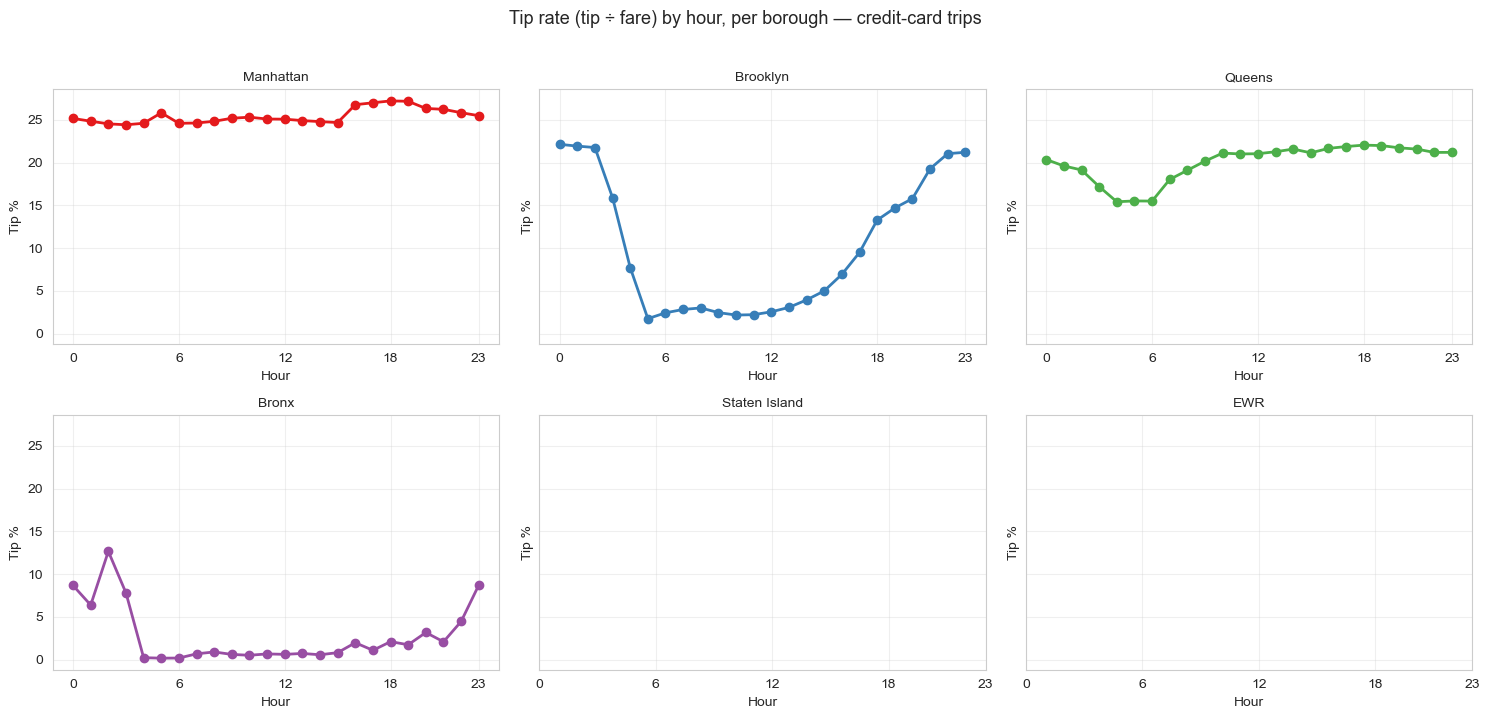

In [33]:
# 7.3 Tip rate per BOROUGH
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
axes = axes.flatten()

for i, borough in enumerate(boroughs_present):
    sub = card[card['PUBorough'] == borough]
    if len(sub) > 100:
        sub_by_hour = sub.groupby('pickup_hour')['tip_pct'].mean() * 100
        axes[i].plot(sub_by_hour.index, sub_by_hour.values, 'o-',
                      color=BOROUGH_COLORS[borough], linewidth=2)
    axes[i].set_title(f'{borough}', fontsize=10)
    axes[i].set_xlabel('Hour')
    axes[i].set_ylabel('Tip %')
    axes[i].set_xticks([0, 6, 12, 18, 23])
    axes[i].grid(True, alpha=0.3)

for j in range(len(boroughs_present), len(axes)):
    axes[j].axis('off')

plt.suptitle('Tip rate (tip ÷ fare) by hour, per borough — credit-card trips', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '7_3_tip_by_borough.png')
plt.show()

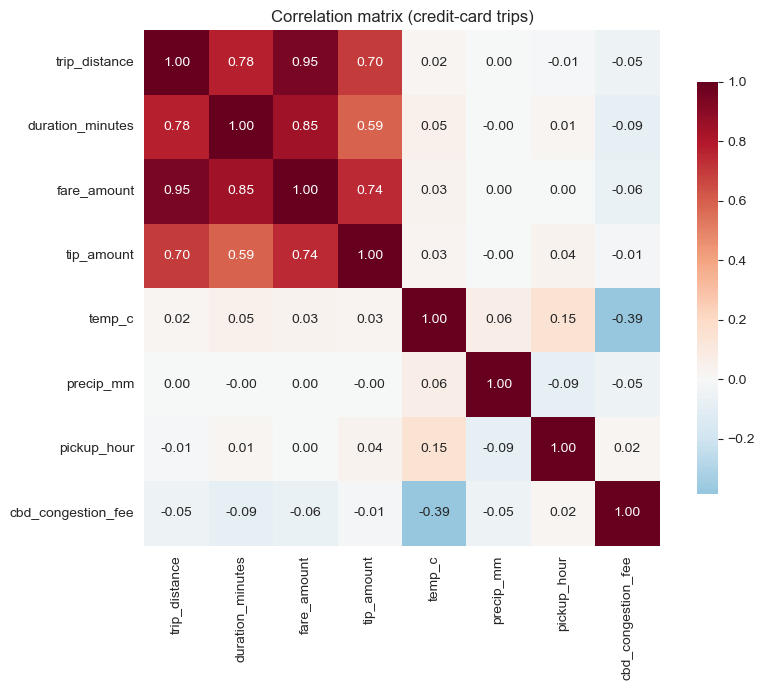

In [34]:
# 7.4 Correlation matrix
corr_cols = ['trip_distance', 'duration_minutes', 'fare_amount', 'tip_amount',
             'temp_c', 'precip_mm', 'pickup_hour', 'cbd_congestion_fee']
# Correlation gives a quick view of numeric relationships.
corr = card[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation matrix (credit-card trips)')
plt.tight_layout()
plt.savefig(FIG_DIR / '7_4_correlation.png')
plt.show()

## Section 8: Summary of key findings

In [35]:
day_labels_full = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

print('=' * 70)
print('KEY FINDINGS — for the report and presentation')
print('=' * 70)

print('\n1. SCALE')
print(f'   • {len(df):,} cleaned trips across 4 months')
for b in boroughs_present:
    n = (df["PUBorough"]==b).sum()
    print(f'     - {b:15s} {n:>10,} ({n/len(df):.2%})')

print('\n2. TEMPORAL PATTERNS')
print(f'   • Peak hour: {hourly.idxmax()}:00')
print(f'   • Lowest hour: {hourly.idxmin()}:00')
print(f'   • Busiest day: {day_labels_full[df["pickup_dayofweek"].value_counts().idxmax()]}')
print(f'   • Different boroughs have different peak times (see 3.2)')

print('\n3. PATTERNS AROUND CONGESTION PRICING LAUNCH (descriptive)')
print(f'   • Pre-policy: {len(pre)/n_pre_days:,.0f} trips/day')
print(f'   • Post-policy: {len(post)/n_post_days:,.0f} trips/day')
print(f'   • Overall change: {(len(post)/n_post_days)/(len(pre)/n_pre_days) - 1:+.1%}')
if 'CBD pickup' in pivot_class.index and 'Non-CBD pickup' in pivot_class.index:
    cbd_change = pivot_class.loc["CBD pickup", "% change"]
    non_cbd_change = pivot_class.loc["Non-CBD pickup", "% change"]
    print(f'   • CBD pickups: {cbd_change:+.1f}%')
    print(f'   • Non-CBD pickups: {non_cbd_change:+.1f}%')
    print(f'   • Descriptive CBD vs non-CBD difference: {cbd_change - non_cbd_change:+.1f} pp')
    print(f'     (formal DID with proper standard errors → Plan B notebook)')

print('\n4. WEATHER EFFECT')
if 'Dry' in trips_per_hour.index:
    print(f'   • Dry hour rate: {trips_per_hour["Dry"]:.0f} trips/hr')
if 'Heavy rain' in trips_per_hour.index:
    print(f'   • Heavy rain hour rate: {trips_per_hour["Heavy rain"]:.0f} trips/hr')

print('\n5. TIPPING')
print(f'   • Median tip rate: {card["tip_pct"].median()*100:.1f}%')
print(f'   • Mean tip rate: {card["tip_pct"].mean()*100:.1f}%')
print(f'   • Top correlation with tip: fare_amount ({corr.loc["tip_amount", "fare_amount"]:.2f})')

print('\n' + '=' * 70)
print('Charts saved to:', FIG_DIR)
print('Pick the best 8–10 for the final report.')
print('=' * 70)

KEY FINDINGS — for the report and presentation

1. SCALE
   • 11,770,077 cleaned trips across 4 months
     - Manhattan       10,645,921 (90.45%)
     - Brooklyn           101,589 (0.86%)
     - Queens             999,190 (8.49%)
     - Bronx               23,059 (0.20%)
     - Staten Island          243 (0.00%)
     - EWR                     75 (0.00%)

2. TEMPORAL PATTERNS
   • Peak hour: 18:00
   • Lowest hour: 4:00
   • Busiest day: Fri
   • Different boroughs have different peak times (see 3.2)

3. PATTERNS AROUND CONGESTION PRICING LAUNCH (descriptive)
   • Pre-policy: 102,114 trips/day
   • Post-policy: 93,322 trips/day
   • Overall change: -8.6%
   • CBD pickups: -9.1%
   • Non-CBD pickups: -7.5%
   • Descriptive CBD vs non-CBD difference: -1.6 pp
     (formal DID with proper standard errors → Plan B notebook)

4. WEATHER EFFECT
   • Dry hour rate: 4119 trips/hr

5. TIPPING
   • Median tip rate: 26.3%
   • Mean tip rate: 25.1%
   • Top correlation with tip: fare_amount (0.74)



# Part 3 — Feature Engineering And Unsupervised Learning

# NYC Taxi Project — Feature Engineering & Unsupervised Learning

**Owner:** Chloe  
**Input:** `clean_trips.parquet` (11.77M rows from Jena)  
**Outputs:**
- `data/processed/feature_matrix_demand.parquet` — primary Plan B file for zone-hour taxi demand prediction
- `data/processed/zone_clusters.csv` — zone cluster labels for unsupervised learning
- `data/processed/feature_matrix_tip.parquet` — optional secondary driver-income / tip-analysis file
- `models/encoders.pkl` — fitted encoders and clustering objects



## Section 1: Setup

In [36]:
from pathlib import Path

# Find the project root automatically so the notebook works from different folders.
PROJECT_ROOT = next(
    p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (p / 'data' / 'processed').exists()
)
# EDA starts from the cleaned trip-level parquet file.
CLEAN_FILE = PROJECT_ROOT / 'data' / 'processed' / 'clean_trips.parquet'
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
MODEL_DIR = PROJECT_ROOT / 'models'
FIG_DIR = PROJECT_ROOT / 'output' / 'figures' / 'fe_unsupervised'
for d in [PROC_DIR, MODEL_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Input:  {CLEAN_FILE}')
print(f'Output: {PROC_DIR}')

Input:  /Users/jason/Documents/5243 final project/data/processed/clean_trips.parquet
Output: /Users/jason/Documents/5243 final project/data/processed


In [37]:
import os
os.environ.setdefault('NUMBA_CACHE_DIR', str(PROJECT_ROOT / '.numba-cache'))
(PROJECT_ROOT / '.numba-cache').mkdir(parents=True, exist_ok=True)

# UMAP is used only for visualization, not as the predictive model.
import umap
print('UMAP available')

UMAP available


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'
sns.set_style('whitegrid')

POLICY_DATE = pd.Timestamp('2025-01-05')

# Load cleaned trips for plotting and summary tables.
df = pd.read_parquet(CLEAN_FILE)
# Standardize weather column names
# Shorter weather names make the plotting code cleaner.
df = df.rename(columns={'temperature': 'temp_c', 'precipitation': 'precip_mm', 'snow': 'snow_mm'})
df['pickup_date'] = pd.to_datetime(df['pickup_date'])

print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')

Loaded 11,770,077 rows × 39 columns


## Section 2: Feature engineering for tip prediction

**Target**: `tip_amount` (or `tip_pct`)  
**Sample**: credit-card trips only (cash tips are not observed)  
**Granularity**: one row per trip

In [39]:
# Filter to credit card trips with reasonable tips
# Build tip features only on credit-card trips.
card = df[df['payment_type'] == 1].copy()
card = card[card['fare_amount'] > 0]
card = card[card['tip_amount'] >= 0]
card = card[card['tip_amount'] <= card['fare_amount'] * 1.5]  # remove unrealistic tips
print(f'Card trips after filtering: {len(card):,}')

Card trips after filtering: 10,030,427


In [40]:
# 2.1 Temporal features
card['hour'] = card['pickup_hour'].astype(np.int8)
card['dayofweek'] = card['pickup_dayofweek'].astype(np.int8)
card['is_weekend'] = card['dayofweek'].isin([5, 6])
card['is_rush_am'] = card['hour'].between(7, 10)
card['is_rush_pm'] = card['hour'].between(17, 20)
card['is_late_night'] = card['hour'].between(0, 4) | (card['hour'] >= 22)
card['is_business_hours'] = card['hour'].between(9, 17) & ~card['is_weekend']
card['month'] = card['pickup_datetime'].dt.month.astype(np.int8)

# Cyclical encoding for hour (so 23 and 0 are close)
card['hour_sin'] = np.sin(2 * np.pi * card['hour'] / 24).astype(np.float32)
card['hour_cos'] = np.cos(2 * np.pi * card['hour'] / 24).astype(np.float32)
card['dow_sin'] = np.sin(2 * np.pi * card['dayofweek'] / 7).astype(np.float32)
card['dow_cos'] = np.cos(2 * np.pi * card['dayofweek'] / 7).astype(np.float32)

print('Temporal features added:')
for c in ['hour', 'dayofweek', 'is_weekend', 'is_rush_am', 'is_rush_pm',
          'is_late_night', 'is_business_hours', 'month',
          'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']:
    print(f'  ✓ {c}')

Temporal features added:
  ✓ hour
  ✓ dayofweek
  ✓ is_weekend
  ✓ is_rush_am
  ✓ is_rush_pm
  ✓ is_late_night
  ✓ is_business_hours
  ✓ month
  ✓ hour_sin
  ✓ hour_cos
  ✓ dow_sin
  ✓ dow_cos


In [41]:
# 2.2 Spatial features
# Airport trips behave differently, so flag airport zones.
AIRPORT_IDS = {132, 138, 1}  # JFK, LGA, EWR

card['is_pu_airport'] = card['PULocationID'].isin(AIRPORT_IDS)
card['is_do_airport'] = card['DOLocationID'].isin(AIRPORT_IDS)
card['is_airport_trip'] = card['is_pu_airport'] | card['is_do_airport']
card['is_intra_borough'] = card['PUBorough'] == card['DOBorough']
card['is_intra_zone'] = card['PULocationID'] == card['DOLocationID']
card['is_pu_manhattan'] = card['PUBorough'] == 'Manhattan'
card['is_do_manhattan'] = card['DOBorough'] == 'Manhattan'

# CBD flag based on whether the trip incurred congestion fee
# CBD fee is used as a trip-level CBD exposure indicator.
card['is_cbd_trip'] = card['cbd_congestion_fee'] > 0

print('Spatial features added')
print(f'  Airport trip rate: {card["is_airport_trip"].mean():.2%}')
print(f'  Intra-borough rate: {card["is_intra_borough"].mean():.2%}')
print(f'  Manhattan-pickup rate: {card["is_pu_manhattan"].mean():.2%}')

Spatial features added
  Airport trip rate: 9.25%
  Intra-borough rate: 87.44%
  Manhattan-pickup rate: 90.82%


In [42]:
# 2.3 Trip economics features
card['fare_per_mile'] = (card['fare_amount'] / card['trip_distance'].clip(lower=0.1)).astype(np.float32)
card['fare_per_minute'] = (card['fare_amount'] / card['duration_minutes'].clip(lower=0.5)).astype(np.float32)
card['has_extras'] = (card['extra'] + card['tolls_amount'] + card['airport_fee'] > 0)
card['has_congestion_fee'] = card['cbd_congestion_fee'] > 0

# Log-transformed for skewed distributions
card['log_fare'] = np.log1p(card['fare_amount']).astype(np.float32)
card['log_distance'] = np.log1p(card['trip_distance']).astype(np.float32)
card['log_duration'] = np.log1p(card['duration_minutes']).astype(np.float32)

print('Economic features added')

Economic features added


In [43]:
# 2.4 Weather features (already joined by Jena, just normalize)
card['precip_mm'] = card['precip_mm'].fillna(0).astype(np.float32)
card['is_rainy'] = card['precip_mm'] > 0.5
card['is_heavy_rain'] = card['precip_mm'] > 2.5
card['is_freezing'] = card['temp_c'] <= 0
card['is_snowing'] = (card['temp_c'] <= 0) & (card['precip_mm'] > 0.1)
card['temp_bucket'] = pd.cut(card['temp_c'], bins=[-30, 0, 10, 20, 35],
                              labels=['cold', 'cool', 'mild', 'warm']).astype('category')

print('Weather features added')
print(f'  Rainy trip rate: {card["is_rainy"].mean():.2%}')
print(f'  Snowing trip rate: {card["is_snowing"].mean():.2%}')

Weather features added
  Rainy trip rate: 4.61%
  Snowing trip rate: 1.42%


In [44]:


# Global mean is the fallback value for target encoding.
GLOBAL_TIP_MEAN = card['tip_amount'].mean()
SMOOTH = 100  # smoothing factor; lower = more aggressive encoding

def target_encode(series, target, smooth=SMOOTH, global_mean=None):
    if global_mean is None:
        global_mean = target.mean()
    agg = target.groupby(series).agg(['mean', 'count'])
    smoothed = (agg['count'] * agg['mean'] + smooth * global_mean) / (agg['count'] + smooth)
    return series.map(smoothed).astype(np.float32), smoothed

card['pu_zone_tip_enc'], pu_zone_enc = target_encode(
    card['PULocationID'], card['tip_amount'], global_mean=GLOBAL_TIP_MEAN
)
card['do_zone_tip_enc'], do_zone_enc = target_encode(
    card['DOLocationID'], card['tip_amount'], global_mean=GLOBAL_TIP_MEAN
)

print('Target encodings:')
print(f'  PU zone: {len(pu_zone_enc)} unique zones encoded')
print(f'  DO zone: {len(do_zone_enc)} unique zones encoded')
print(f'  Global tip mean: ${GLOBAL_TIP_MEAN:.2f}')

Target encodings:
  PU zone: 254 unique zones encoded
  DO zone: 258 unique zones encoded
  Global tip mean: $4.19


In [45]:
# 2.6 Compose final feature matrix for tip modeling
feature_cols = [
    # Temporal
    'hour', 'dayofweek', 'month',
    'is_weekend', 'is_rush_am', 'is_rush_pm', 'is_late_night', 'is_business_hours',
    'is_holiday',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    # Spatial
    'is_pu_airport', 'is_do_airport', 'is_airport_trip',
    'is_intra_borough', 'is_intra_zone',
    'is_pu_manhattan', 'is_do_manhattan', 'is_cbd_trip',
    # Economics
    'trip_distance', 'duration_minutes', 'fare_amount',
    'fare_per_mile', 'fare_per_minute',
    'log_fare', 'log_distance', 'log_duration',
    'has_extras', 'has_congestion_fee',
    'passenger_count',
    # Weather
    'temp_c', 'precip_mm', 'is_rainy', 'is_heavy_rain', 'is_freezing', 'is_snowing',
    # Policy
    'post_congestion_fee', 'cbd_congestion_fee',
    # Target encodings
    'pu_zone_tip_enc', 'do_zone_tip_enc',
    # IDs (kept for joining; drop before training)
    'PULocationID', 'DOLocationID', 'PUBorough', 'DOBorough',
]
target_cols = ['tip_amount']

tip_features = card[feature_cols + target_cols].copy()

# Convert booleans to int8 for tree models
bool_cols = [c for c in tip_features.columns if tip_features[c].dtype == bool]
for c in bool_cols:
    tip_features[c] = tip_features[c].astype(np.int8)

print(f'Tip feature matrix: {tip_features.shape}')
print(f'Memory: {tip_features.memory_usage(deep=True).sum() / 1e9:.2f} GB')
print('\nDtype summary:')
print(tip_features.dtypes.value_counts())

Tip feature matrix: (10030427, 47)
Memory: 1.18 GB

Dtype summary:
int8        24
float32     19
int32        2
category     2
Name: count, dtype: int64


In [46]:
# Save tip feature matrix
# Save this optional trip-level feature matrix for tip analysis.
tip_features.to_parquet(
    PROC_DIR / 'feature_matrix_tip.parquet',
    index=False, compression='snappy'
)
size_mb = (PROC_DIR / 'feature_matrix_tip.parquet').stat().st_size / 1e6
print(f'✓ Saved feature_matrix_tip.parquet ({size_mb:.0f} MB)')

✓ Saved feature_matrix_tip.parquet (210 MB)


## Section 3: Feature engineering for demand prediction 



In [47]:
# Aggregate trips to zone × hour level
# Demand prediction uses one row per pickup zone and hour.
df['hour_ts'] = df['pickup_datetime'].dt.floor('h')

# Aggregate trips to create the demand target.
demand = df.groupby(['PULocationID', 'hour_ts'], observed=True).agg(
    n_trips=('fare_amount', 'count'),
    avg_fare=('fare_amount', 'mean'),
    avg_distance=('trip_distance', 'mean'),
    avg_duration=('duration_minutes', 'mean'),
    avg_speed=('avg_speed_mph', 'mean'),
    n_card=('payment_type', lambda x: (x == 1).sum()),
).reset_index()

print(f'Demand panel: {len(demand):,} rows (zone × hour combinations)')
print(demand.head())

Demand panel: 283,202 rows (zone × hour combinations)
   PULocationID             hour_ts  n_trips    avg_fare  avg_distance  \
0             1 2024-11-03 15:00:00        1   25.000000          1.60   
1             1 2024-11-03 16:00:00        1   31.400000          1.95   
2             1 2024-11-05 01:00:00        1   83.900002         16.83   
3             1 2024-11-05 17:00:00        1  138.100006         16.18   
4             1 2024-11-11 08:00:00        1   70.000000          0.01   

   avg_duration  avg_speed  n_card  
0      7.966667  12.050209       1  
1      7.800000  15.000000       1  
2     30.533333  33.072052       1  
3     43.916668  22.105503       1  
4      4.166667   0.144000       1  


In [48]:
# Build complete zone × hour panel including zero-trip hours
all_hours = pd.date_range(
    df['hour_ts'].min(),
    df['hour_ts'].max(),
    freq='h'
)
all_zones = sorted(df['PULocationID'].dropna().unique())

# Build a complete zone-hour panel, including zero-trip hours.
full_index = pd.MultiIndex.from_product(
    [all_zones, all_hours],
    names=['PULocationID', 'hour_ts']
)

# Reindex to full panel; missing combinations become NaN
demand = (
    demand.set_index(['PULocationID', 'hour_ts'])
          .reindex(full_index)
          .reset_index()
)

# Fill counts with 0 (zero trips means literally zero)
# Missing combinations after reindexing mean zero observed trips.
demand['n_trips'] = demand['n_trips'].fillna(0).astype(np.int32)
demand['n_card'] = demand['n_card'].fillna(0).astype(np.int32)

# For trip-average columns, no trips → no average
# Fill with 0 for modeling and add a "_missing" indicator
for col in ['avg_fare', 'avg_distance', 'avg_duration', 'avg_speed']:
    demand[f'{col}_missing'] = demand[col].isna().astype(np.int8)
    demand[col] = demand[col].fillna(0).astype(np.float32)

print(f'Complete demand panel: {len(demand):,} rows')
print(f'  Zones: {demand["PULocationID"].nunique()}')
print(f'  Hours: {demand["hour_ts"].nunique()}')
print(f'  Zero-trip hours: {(demand["n_trips"] == 0).sum():,} ({(demand["n_trips"] == 0).mean():.1%})')

Complete demand panel: 745,920 rows
  Zones: 259
  Hours: 2880
  Zero-trip hours: 462,718 (62.0%)


In [49]:
# Add temporal context
demand['hour'] = demand['hour_ts'].dt.hour.astype(np.int8)
demand['dayofweek'] = demand['hour_ts'].dt.dayofweek.astype(np.int8)
demand['month'] = demand['hour_ts'].dt.month.astype(np.int8)
demand['date'] = demand['hour_ts'].dt.date
demand['is_weekend'] = demand['dayofweek'].isin([5, 6]).astype(np.int8)
# Sine/cosine preserve the circular pattern of hours.
demand['hour_sin'] = np.sin(2 * np.pi * demand['hour'] / 24).astype(np.float32)
demand['hour_cos'] = np.cos(2 * np.pi * demand['hour'] / 24).astype(np.float32)
demand['post_policy'] = demand['hour_ts'] >= POLICY_DATE

# Join holiday flag
# Holiday matching only needs the pickup date.
holiday_dates = set(df.loc[df['is_holiday'], 'pickup_date'].dt.date.unique())
demand['is_holiday'] = demand['date'].isin(holiday_dates).astype(np.int8)

# Join zone borough
zone_borough = df.drop_duplicates('PULocationID').set_index('PULocationID')['PUBorough'].to_dict()
demand['borough'] = demand['PULocationID'].map(zone_borough).astype('category')
demand['is_manhattan'] = (demand['borough'] == 'Manhattan').astype(np.int8)
demand['is_airport'] = demand['PULocationID'].isin(AIRPORT_IDS).astype(np.int8)

# Add DID variables for Plan B policy analysis
post_df = df[df['pickup_datetime'] >= POLICY_DATE]

# Estimate treated CBD zones from observed post-policy fees.
zone_fee_rate = (
    post_df.groupby('PULocationID')['cbd_congestion_fee']
    .apply(lambda x: (x > 0).mean())
)

CBD_ZONES = set(zone_fee_rate[zone_fee_rate > 0.5].index)

demand['treated_zone'] = demand['PULocationID'].isin(CBD_ZONES).astype(np.int8)
demand['post_policy'] = demand['post_policy'].astype(np.int8)
# DID interaction identifies treated zones after policy starts.
demand['did'] = demand['treated_zone'] * demand['post_policy']

print(f'Empirical CBD-treated zones: {len(CBD_ZONES)}')

print('Temporal/spatial context added.')

Empirical CBD-treated zones: 44
Temporal/spatial context added.


In [50]:
# Lag features for time series modeling
demand = demand.sort_values(['PULocationID', 'hour_ts']).reset_index(drop=True)
# Lag features use past demand only, avoiding future leakage.
demand['n_trips_lag_1h'] = demand.groupby('PULocationID')['n_trips'].shift(1)
demand['n_trips_lag_24h'] = demand.groupby('PULocationID')['n_trips'].shift(24)
demand['n_trips_lag_168h'] = demand.groupby('PULocationID')['n_trips'].shift(168)  # 1 week
demand['n_trips_ma_24h'] = demand.groupby('PULocationID')['n_trips'].transform(
    lambda x: x.rolling(24, min_periods=1).mean().shift(1)
).astype(np.float32)

print('Lag features added (1h, 24h, 168h, 24h moving average).')
print(f'Rows with all lags non-null: {demand.dropna(subset=["n_trips_lag_168h"]).shape[0]:,}')

Lag features added (1h, 24h, 168h, 24h moving average).
Rows with all lags non-null: 702,408


In [51]:
# Join hourly weather
# Need a fresh hourly weather table because the demand panel has full zone-hour granularity.
# Use one weather row per hour before merging to the demand panel.
weather = (
    df.drop_duplicates('hour_ts')
      .set_index('hour_ts')[['temp_c', 'precip_mm', 'humidity', 'wind_speed']]
)

demand = demand.merge(
    weather,
    left_on='hour_ts',
    right_index=True,
    how='left'
)

# Check missing values after weather merge
weather_cols = ['temp_c', 'precip_mm', 'humidity', 'wind_speed']

print('Missing weather values before filling:')
print(demand[weather_cols].isna().sum())

# Fill precipitation with 0
# Missing precipitation is treated as no recorded precipitation.
demand['precip_mm'] = demand['precip_mm'].fillna(0).astype(np.float32)

# Fill continuous weather variables using forward/backward fill
# Weather changes smoothly over time, so this is reasonable for hourly data.
for col in ['temp_c', 'humidity', 'wind_speed']:
    demand[col] = demand[col].ffill().bfill().astype(np.float32)

# Re-create rainy flag after filling precipitation
demand['is_rainy'] = (demand['precip_mm'] > 0.5).astype(np.int8)

print('\nMissing weather values after filling:')
print(demand[weather_cols].isna().sum())

print('Weather features added and missing values handled.')

Missing weather values before filling:
temp_c           0
precip_mm     1295
humidity         0
wind_speed       0
dtype: int64

Missing weather values after filling:
temp_c        0
precip_mm     0
humidity      0
wind_speed    0
dtype: int64
Weather features added and missing values handled.


In [52]:
# Save demand feature matrix
# Drop rows that do not yet have a full one-week lag.
demand_clean = demand.dropna(subset=['n_trips_lag_168h']).copy()
print(f'Final demand panel rows (after dropping NaNs in lags): {len(demand_clean):,}')

demand_clean.to_parquet(
    PROC_DIR / 'feature_matrix_demand.parquet',
    index=False, compression='snappy'
)
size_mb = (PROC_DIR / 'feature_matrix_demand.parquet').stat().st_size / 1e6
print(f'✓ Saved feature_matrix_demand.parquet ({size_mb:.0f} MB)')

Final demand panel rows (after dropping NaNs in lags): 702,408
✓ Saved feature_matrix_demand.parquet (9 MB)


## Section 4: Zone clustering (unsupervised )


In [53]:
# Aggregate trip-level data into zone-level feature vectors
# Summarize each zone for clustering.
zone_features = df.groupby('PULocationID', observed=True).agg(
    n_trips=('fare_amount', 'count'),
    avg_fare=('fare_amount', 'mean'),
    avg_distance=('trip_distance', 'mean'),
    avg_duration=('duration_minutes', 'mean'),
    avg_speed=('avg_speed_mph', 'mean'),
    pct_card=('payment_type', lambda x: (x == 1).mean()),
    pct_weekend=('pickup_dayofweek', lambda x: x.isin([5, 6]).mean()),
    pct_night=('pickup_hour', lambda x: ((x < 6) | (x >= 22)).mean()),
    pct_rush=('pickup_hour', lambda x: x.between(7, 10).mean() + x.between(17, 20).mean()),
    pct_cbd_fee=('cbd_congestion_fee', lambda x: (x > 0).mean()),
).round(3)

# Add hourly entropy as a measure of how concentrated demand is in time
from scipy.stats import entropy
# Hourly entropy measures whether demand is concentrated or spread out.
hour_dist = df.groupby(['PULocationID', 'pickup_hour'], observed=True).size().unstack(fill_value=0)
hour_dist_norm = hour_dist.div(hour_dist.sum(axis=1), axis=0)
zone_features['hour_entropy'] = hour_dist_norm.apply(
    lambda r: entropy(r + 1e-9), axis=1
).round(3)

# Filter to zones with enough data (avoid noisy clusters)
MIN_TRIPS = 100
zone_features = zone_features[zone_features['n_trips'] >= MIN_TRIPS].copy()
print(f'Zones with >= {MIN_TRIPS} trips: {len(zone_features)}')
print(zone_features.head())

Zones with >= 100 trips: 222
              n_trips   avg_fare  avg_distance  avg_duration  avg_speed  \
PULocationID                                                              
3                 335  41.338001        11.119     53.625999  13.719000   
4               13480  16.040001         2.713     14.326000  11.053000   
6                 181   2.268000         6.549     15.047000  33.398998   
7                4258  20.801001         3.648     19.087000  11.897000   
9                 152  31.715000         7.787     35.055000  14.343000   

              pct_card  pct_weekend  pct_night  pct_rush  pct_cbd_fee  \
PULocationID                                                            
3                0.967        0.137      0.182     0.370        0.003   
4                0.886        0.609      0.677     0.173        0.439   
6                0.017        0.287      0.066     0.138        0.011   
7                0.545        0.296      0.180     0.380        0.100   
9      

In [54]:
# Standardize features for clustering
feature_for_cluster = ['avg_fare', 'avg_distance', 'avg_duration', 'avg_speed',
                       'pct_card', 'pct_weekend', 'pct_night', 'pct_rush',
                       'pct_cbd_fee', 'hour_entropy']
X = zone_features[feature_for_cluster].values
scaler = StandardScaler()
# Scale zone features before distance-based clustering.
X_scaled = scaler.fit_transform(X)

# Try k from 3 to 10 using silhouette score
k_range = range(3, 11)
scores = []
# Try several k values and compare silhouette scores.
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print(f'  k={k}: silhouette = {score:.3f}')

best_k = k_range[np.argmax(scores)]
print(f'\nBest k by silhouette: {best_k}')

  k=3: silhouette = 0.368
  k=4: silhouette = 0.371
  k=5: silhouette = 0.320
  k=6: silhouette = 0.277
  k=7: silhouette = 0.266
  k=8: silhouette = 0.264
  k=9: silhouette = 0.266
  k=10: silhouette = 0.262

Best k by silhouette: 4


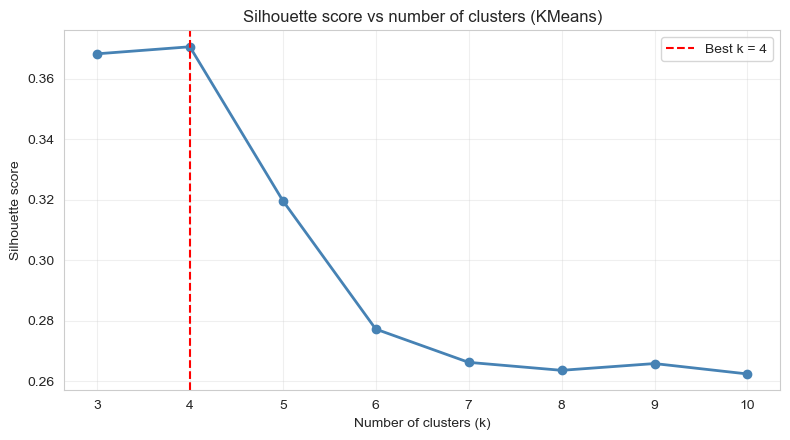

In [55]:
# Plot silhouette curve
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(list(k_range), scores, 'o-', linewidth=2, color='steelblue')
ax.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Silhouette score')
ax.set_title('Silhouette score vs number of clusters (KMeans)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fe_silhouette.png')
plt.show()

In [56]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Final clustering using best k from silhouette score
# Fit the final KMeans model using the chosen k.
kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_SEED,
    n_init=10
)

zone_features['kmeans_cluster'] = kmeans_final.fit_predict(X_scaled).astype(np.int8)

agg_final = AgglomerativeClustering(
    n_clusters=best_k,
    linkage='ward'
)

zone_features['hier_cluster'] = agg_final.fit_predict(X_scaled).astype(np.int8)

# Label-invariant clustering comparison
ari = adjusted_rand_score(
    zone_features['kmeans_cluster'],
    zone_features['hier_cluster']
)

nmi = normalized_mutual_info_score(
    zone_features['kmeans_cluster'],
    zone_features['hier_cluster']
)

print('KMeans vs hierarchical clustering agreement (label-invariant):')
print(f'  Best k: {best_k}')
print(f'  Adjusted Rand Index: {ari:.3f}')
print(f'  Normalized Mutual Info: {nmi:.3f}')
print('  (1.0 = identical structure; 0.0 = random; >0.5 = strong agreement)')

KMeans vs hierarchical clustering agreement (label-invariant):
  Best k: 4
  Adjusted Rand Index: 0.725
  Normalized Mutual Info: 0.715
  (1.0 = identical structure; 0.0 = random; >0.5 = strong agreement)


In [57]:
# Interpret clusters: show mean feature values per cluster
cluster_summary = zone_features.groupby('kmeans_cluster')[feature_for_cluster].mean().round(2)
cluster_summary['n_zones'] = zone_features.groupby('kmeans_cluster').size()
print('KMeans cluster profiles:')
print(cluster_summary.T)

KMeans cluster profiles:
kmeans_cluster          0          1       2      3
avg_fare        18.740000  44.919998   35.98  21.49
avg_distance     3.220000   8.440000    8.93   3.61
avg_duration    18.049999  31.129999   46.82  18.65
avg_speed       10.630000  20.430000   12.27  11.80
pct_card         0.810000   0.750000    0.92   0.86
pct_weekend      0.270000   0.270000    0.19   0.46
pct_night        0.140000   0.160000    0.09   0.45
pct_rush         0.430000   0.360000    0.44   0.27
pct_cbd_fee      0.230000   0.080000    0.01   0.27
hour_entropy     2.940000   2.950000    2.75   2.98
n_zones         71.000000  30.000000  106.00  15.00


In [58]:
# Pull in zone names to label clusters
zone_names = df.drop_duplicates('PULocationID').set_index('PULocationID')[
    ['PUZone', 'PUBorough']
]
zone_names.columns = ['zone_name', 'borough']
zones_labeled = zone_features.join(zone_names)

print('Sample zones in each KMeans cluster:')
for c in sorted(zones_labeled['kmeans_cluster'].unique()):
    sample = zones_labeled[zones_labeled['kmeans_cluster'] == c].head(5)
    print(f'\n  Cluster {c} ({len(zones_labeled[zones_labeled["kmeans_cluster"] == c])} zones):')
    for _, row in sample.iterrows():
        print(f'    {row["zone_name"]} ({row["borough"]})')

Sample zones in each KMeans cluster:

  Cluster 0 (71 zones):
    Astoria (Queens)
    Battery Park (Manhattan)
    Battery Park City (Manhattan)
    Bloomingdale (Manhattan)
    Boerum Hill (Brooklyn)

  Cluster 1 (30 zones):
    Arrochar/Fort Wadsworth (Staten Island)
    Baisley Park (Queens)
    Bayside (Queens)
    Briarwood/Jamaica Hills (Queens)
    Corona (Queens)

  Cluster 2 (106 zones):
    Allerton/Pelham Gardens (Bronx)
    Auburndale (Queens)
    Bath Beach (Brooklyn)
    Bay Ridge (Brooklyn)
    Bay Terrace/Fort Totten (Queens)

  Cluster 3 (15 zones):
    Alphabet City (Manhattan)
    Brooklyn Navy Yard (Brooklyn)
    Bushwick North (Brooklyn)
    East Village (Manhattan)
    East Williamsburg (Brooklyn)


In [59]:
# Save zone clusters
out = zones_labeled.reset_index()[
    ['PULocationID', 'zone_name', 'borough', 'kmeans_cluster', 'hier_cluster']
]
out.to_csv(PROC_DIR / 'zone_clusters.csv', index=False)
print(f'✓ Saved zone_clusters.csv ({len(out)} zones)')

✓ Saved zone_clusters.csv (222 zones)


## Section 5: PCA visualization

Visualize the zone feature space in 2D to see if clusters separate cleanly.

PCA explained variance: PC1=44.1%, PC2=22.2%, cumulative=66.3%


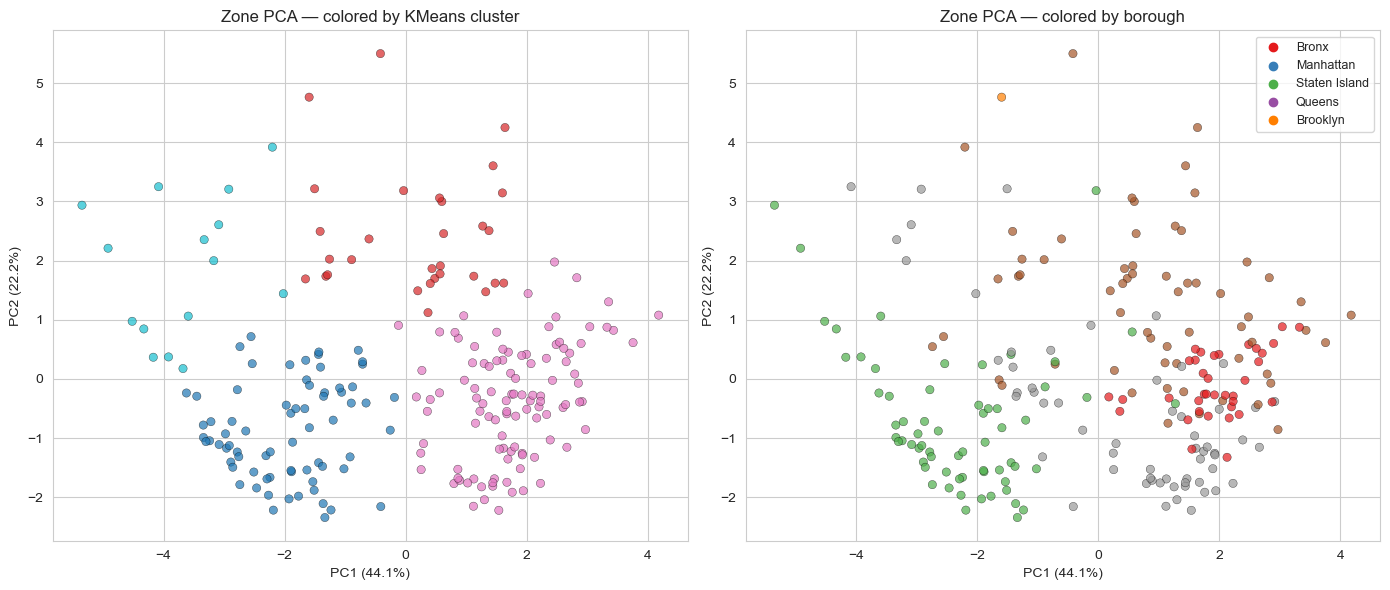

In [60]:
# Reduce zone features to two dimensions for visualization.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f'PCA explained variance: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}, '
      f'cumulative={explained.sum():.1%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Color by cluster
colors = plt.cm.tab10(zone_features['kmeans_cluster'])
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=zone_features['kmeans_cluster'],
                cmap='tab10', alpha=0.7, edgecolor='k', linewidth=0.3)
axes[0].set_xlabel(f'PC1 ({explained[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({explained[1]:.1%})')
axes[0].set_title('Zone PCA — colored by KMeans cluster')

# Color by borough
borough_map = {b: i for i, b in enumerate(zones_labeled['borough'].unique())}
borough_colors = zones_labeled['borough'].map(borough_map)
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=borough_colors,
                            cmap='Set1', alpha=0.7, edgecolor='k', linewidth=0.3)
axes[1].set_xlabel(f'PC1 ({explained[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({explained[1]:.1%})')
axes[1].set_title('Zone PCA — colored by borough')
# Custom legend
for b, i in borough_map.items():
    axes[1].scatter([], [], c=plt.cm.Set1(i), label=b)
axes[1].legend(loc='best', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fe_zone_pca.png')
plt.show()

## Section 6: UMAP — exploratory pre/post policy visualization

Take a sample of zone-hour demand rows, embed via UMAP, and explore whether pre/post policy patterns look different.

In [61]:
# Sample rows so UMAP is feasible on a laptop.
sample_size = min(50_000, len(demand_clean))
sample = demand_clean.sample(n=sample_size, random_state=RANDOM_SEED)

umap_features = [
    'n_trips', 'avg_fare', 'avg_distance', 'avg_duration',
    'avg_speed', 'n_trips_lag_1h', 'n_trips_lag_24h',
    'n_trips_lag_168h', 'n_trips_ma_24h',
    'hour', 'dayofweek', 'temp_c', 'precip_mm',
]

X_um = sample[umap_features].fillna(0).values
# Scale UMAP inputs so large-magnitude variables do not dominate.
X_um_scaled = StandardScaler().fit_transform(X_um)

print(f'Running UMAP on {sample_size:,} demand rows...')
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_SEED)
embedding = reducer.fit_transform(X_um_scaled)
print('Done.')

Running UMAP on 50,000 demand rows...
Done.


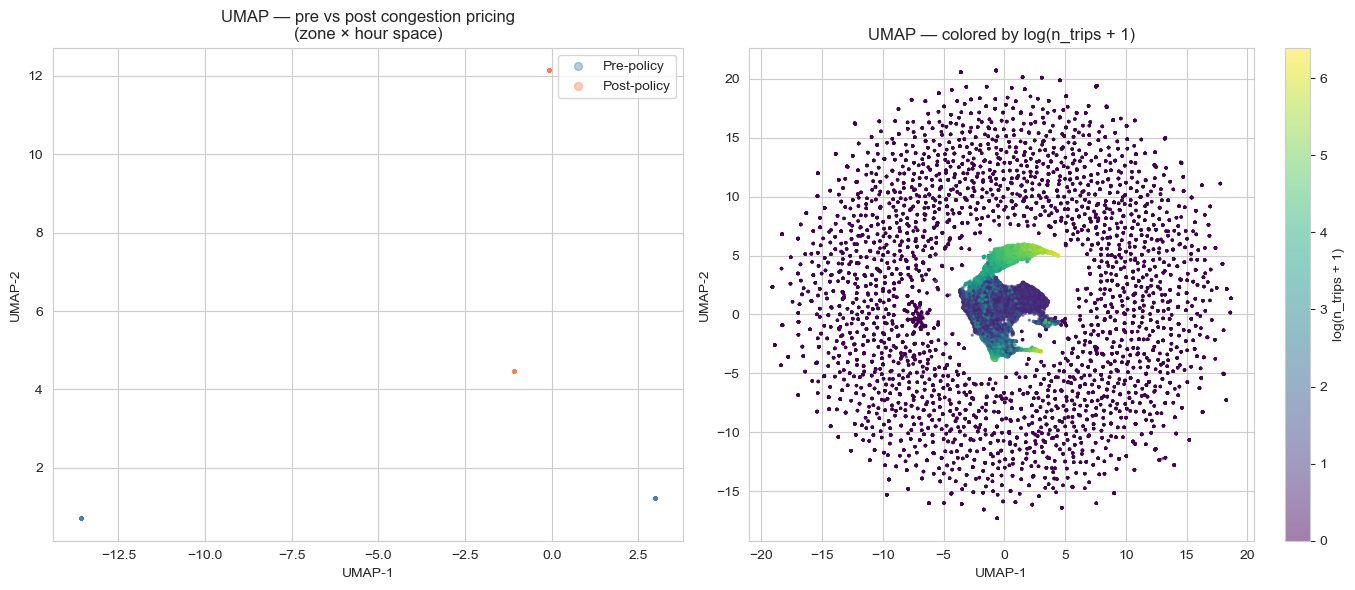

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

post_mask = sample['post_policy'].values
axes[0].scatter(embedding[~post_mask, 0], embedding[~post_mask, 1],
                s=2, alpha=0.4, label='Pre-policy', color='steelblue')
axes[0].scatter(embedding[post_mask, 0], embedding[post_mask, 1],
                s=2, alpha=0.4, label='Post-policy', color='coral')
axes[0].set_title('UMAP — pre vs post congestion pricing\n(zone × hour space)')
axes[0].legend(markerscale=4)
axes[0].set_xlabel('UMAP-1')
axes[0].set_ylabel('UMAP-2')

sc = axes[1].scatter(embedding[:, 0], embedding[:, 1],
                     s=2, alpha=0.5,
                     c=np.log1p(sample['n_trips']),
                     cmap='viridis')
axes[1].set_title('UMAP — colored by log(n_trips + 1)')
axes[1].set_xlabel('UMAP-1')
axes[1].set_ylabel('UMAP-2')
plt.colorbar(sc, ax=axes[1], label='log(n_trips + 1)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fe_umap.png')
plt.show()

## Section 7: Save artifacts and summary

In [63]:
# Save fitted encoders for reproducibility
# Save fitted preprocessing and clustering objects for reproducibility.
encoders = {
    'pu_zone_tip_enc': pu_zone_enc,
    'do_zone_tip_enc': do_zone_enc,
    'global_tip_mean': GLOBAL_TIP_MEAN,
    'cluster_scaler': scaler,
    'kmeans': kmeans_final,
    'best_k': best_k,
    'pca': pca,
    'cluster_features': feature_for_cluster,
}
joblib.dump(encoders, MODEL_DIR / 'encoders.pkl')
print(f'✓ Saved encoders.pkl')

print('\n' + '=' * 70)
print('FE PIPELINE SUMMARY')
print('=' * 70)
print(f'\nTip prediction matrix:    {tip_features.shape}')
print(f'Demand prediction matrix: {demand_clean.shape}')
print(f'Zone clusters:            {len(out)} zones in {best_k} clusters')
print(f'\nFiles produced:')
for f in PROC_DIR.glob('*'):
    if f.is_file():
        size_mb = f.stat().st_size / 1e6
        print(f'  {f.name:40s} {size_mb:>7.1f} MB')
for f in MODEL_DIR.glob('*'):
    if f.is_file():
        size_mb = f.stat().st_size / 1e6
        print(f'  {f.name:40s} {size_mb:>7.1f} MB')
print()
print('Hand off to modeling team:')
print('  Primary file: feature_matrix_demand.parquet')
print('  Target column: n_trips')
print('  Secondary optional file: feature_matrix_tip.parquet')
print('  Zone cluster file: zone_clusters.csv')
print('  Filter columns to drop before training:')
print('  Suggested columns to drop or encode before demand modeling:')
print('    hour_ts, date, borough')
print('    PULocationID can be kept as categorical/id feature or joined with zone_clusters.csv')

✓ Saved encoders.pkl

FE PIPELINE SUMMARY

Tip prediction matrix:    (10030427, 47)
Demand prediction matrix: (702408, 35)
Zone clusters:            222 zones in 4 clusters

Files produced:
  feature_matrix_demand.parquet                8.7 MB
  .DS_Store                                    0.0 MB
  feature_matrix_tip.parquet                 209.6 MB
  data_quality_report.md                       0.0 MB
  clean_trips.parquet                        354.1 MB
  cleaning_log.csv                             0.0 MB
  clean_trips.csv                           3126.7 MB
  zone_clusters.csv                            0.0 MB
  encoders.pkl                                 0.0 MB

Hand off to modeling team:
  Primary file: feature_matrix_demand.parquet
  Target column: n_trips
  Secondary optional file: feature_matrix_tip.parquet
  Zone cluster file: zone_clusters.csv
  Filter columns to drop before training:
  Suggested columns to drop or encode before demand modeling:
    hour_ts, date, borough
 

 Modeling — NYC Taxi Zone-Hour Demand





## Modeling Plan

We use a time-aware validation setup because taxi demand is sequential.

- Target: zone-hour taxi demand, usually `n_trips`, `trip_count`, `demand`, `taxi_demand`, or `num_trips`.
- Split: earlier 80% of hours for training, latest 20% for testing.
- Models: Poisson Regression, Random Forest, Gradient Boosting, and optional Ridge baseline.
- Metrics: MAE, RMSE, R², and SMAPE.
- Outputs: saved `.pkl` models, comparison table, plots, and a short modeling summary.

In [64]:
# Imports and configuration
from pathlib import Path
import warnings
import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
# LightGBM is the main performance model for tabular demand data.
from lightgbm import LGBMRegressor

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import PoissonRegressor, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.matplotlib-cache'))

RANDOM_STATE = 42
POLICY_DATE = pd.Timestamp('2025-01-05')
# Keep tuning off for a fast first run; set True for final tuning.
RUN_TUNING = False         # Set True for a slower tuned final run
MAX_CV_ROWS = 100_000      # Hyperparameter tuning uses the latest training rows
CV_SPLITS = 5
MAX_PLOT_POINTS = 10_000

# Find the project root automatically so the notebook works from different folders.
PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'data' / 'processed').exists()
)
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
MODEL_DIR = PROJECT_ROOT / 'models'
OUT_DIR = PROJECT_ROOT / 'outputs' / 'modeling'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Processed data:', PROC_DIR)
print('Models output:', MODEL_DIR)
print('Modeling output:', OUT_DIR)
print('Boosting backend: LightGBM')

Project root: /Users/jason/Documents/5243 final project
Processed data: /Users/jason/Documents/5243 final project/data/processed
Models output: /Users/jason/Documents/5243 final project/models
Modeling output: /Users/jason/Documents/5243 final project/outputs/modeling
Boosting backend: LightGBM


## 1. Load Or Create Zone-Hour Feature Matrix

The modeling input is `data/processed/feature_matrix_demand.parquet`, created by the feature-engineering section.

In [65]:
# Modeling starts from the zone-hour demand matrix.
feature_path = PROC_DIR / 'feature_matrix_demand.parquet'
if not feature_path.exists():
    raise FileNotFoundError(
        f'Missing {feature_path}. Run the feature engineering section first to create it.'
    )

print('Using feature matrix:', feature_path)
df = pd.read_parquet(feature_path)
print('Shape:', df.shape)
df.head()

Using feature matrix: /Users/jason/Documents/5243 final project/data/processed/feature_matrix_demand.parquet
Shape: (702408, 35)


,PULocationID,hour_ts,n_trips,avg_fare,avg_distance,avg_duration,avg_speed,n_card,avg_fare_missing,avg_distance_missing,...,did,n_trips_lag_1h,n_trips_lag_24h,n_trips_lag_168h,n_trips_ma_24h,temp_c,precip_mm,humidity,wind_speed,is_rainy
0,1,2024-11-08 00:00:00,0,0.0,0.0,0.0,0.0,0,1,1,...,0,0.0,0.0,0.0,0.0,15.8,0.0,46.0,11.0,0
1,1,2024-11-08 01:00:00,0,0.0,0.0,0.0,0.0,0,1,1,...,0,0.0,0.0,0.0,0.0,14.8,0.0,46.0,7.0,0
2,1,2024-11-08 02:00:00,0,0.0,0.0,0.0,0.0,0,1,1,...,0,0.0,0.0,0.0,0.0,13.8,0.0,49.0,15.8,0
3,1,2024-11-08 03:00:00,0,0.0,0.0,0.0,0.0,0,1,1,...,0,0.0,0.0,0.0,0.0,12.8,0.0,49.0,7.0,0
4,1,2024-11-08 04:00:00,0,0.0,0.0,0.0,0.0,0,1,1,...,0,0.0,0.0,0.0,0.0,12.8,0.0,51.0,6.0,0


## 2. Identify Target And Time Column

The target should be the count of taxi trips for a zone-hour observation. The time column is used only for time-based splitting and is not used as a raw model feature.

In [66]:
# The target should be the zone-hour trip count.
target_candidates = ['n_trips', 'trip_count', 'demand', 'taxi_demand', 'num_trips']
# The time column is needed for chronological splitting.
time_candidates = ['hour_ts', 'pickup_hour_ts', 'datetime', 'timestamp', 'pickup_datetime', 'hour']

target_col = next((c for c in target_candidates if c in df.columns), None)
time_col = next((c for c in time_candidates if c in df.columns), None)

if target_col is None:
    raise ValueError(f'No demand target found. Tried {target_candidates}. Columns are: {df.columns.tolist()}')
if time_col is None:
    datetime_cols = list(df.select_dtypes(include=['datetime64[ns]', 'datetime64[us]']).columns)
    if datetime_cols:
        time_col = datetime_cols[0]
    else:
        raise ValueError(f'No time column found. Tried {time_candidates}. Columns are: {df.columns.tolist()}')

if not pd.api.types.is_datetime64_any_dtype(df[time_col]):
    df[time_col] = pd.to_datetime(df[time_col], errors='coerce')

print('Target column:', target_col)
print('Time column:', time_col)
print('Target summary:')
df[target_col].describe()

Target column: n_trips
Time column: hour_ts
Target summary:


count    702408.000000
mean         15.709091
std          50.593783
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max         757.000000
Name: n_trips, dtype: float64

## 3. Time-Based Train/Test Split

We sort observations by hour and train on earlier hours. The test set is the latest 20% of the project window, which avoids random time leakage.

In [67]:
# Remove rows missing target or time before splitting.
df_model = df.dropna(subset=[time_col, target_col]).sort_values(time_col).reset_index(drop=True)
unique_times = np.array(sorted(df_model[time_col].dropna().unique()))
# First 80% of timestamps train, latest 20% test.
cutoff_time = unique_times[int(len(unique_times) * 0.80)]

train_df = df_model[df_model[time_col] < cutoff_time].copy()
test_df = df_model[df_model[time_col] >= cutoff_time].copy()

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print('Train time range:', train_df[time_col].min(), 'to', train_df[time_col].max())
print('Test time range:', test_df[time_col].min(), 'to', test_df[time_col].max())

Train shape: (561771, 35)
Test shape: (140637, 35)
Train time range: 2024-11-08 00:00:00 to 2025-02-06 08:00:00
Test time range: 2025-02-06 09:00:00 to 2025-02-28 23:00:00


## 4. Prepare Features

We remove direct leakage columns. Lag and rolling demand features are kept because they are past information. Current-hour aggregate trip statistics such as `n_card` and `avg_fare_missing` are removed because they are only known after the hour is complete.

In [68]:
# Past-demand markers identify safe lag and rolling features.
past_markers = ['lag', 'ma_', 'rolling', 'past', 'prev']
# Drop variables that would reveal current-hour demand after the fact.
leakage_words = [
    'future', 'target', 'actual', 'total_trips', 'total_demand',
    'n_card', 'card_count', 'avg_fare', 'avg_distance', 'avg_duration', 'avg_speed'
]
target_like_words = ['n_trips', 'trip_count', 'taxi_demand', 'num_trips', 'demand']


def is_past_feature(col):
    c = col.lower()
    return any(marker in c for marker in past_markers)


def choose_feature_columns(data, target_col, time_col):
    drop_cols = {target_col, time_col}
    for col in data.columns:
        c = col.lower()
        if col in drop_cols:
            continue
        if pd.api.types.is_datetime64_any_dtype(data[col]) or c in ['date', 'pickup_date']:
            drop_cols.add(col)
        elif any(word in c for word in leakage_words):
            drop_cols.add(col)
        elif any(word in c for word in target_like_words) and not is_past_feature(c):
            drop_cols.add(col)
    return [c for c in data.columns if c not in drop_cols], sorted(drop_cols)


# Finalize usable model columns after leakage filtering.
feature_cols, dropped_cols = choose_feature_columns(df_model, target_col, time_col)

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()
y_train = train_df[target_col].astype(float)
y_test = test_df[target_col].astype(float)

# Zone IDs and cluster labels are categorical, not continuous measurements.
for col in ['PULocationID', 'pickup_zone_id', 'zone_id', 'zone_cluster', 'borough', 'PUBorough']:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('category')
        X_test[col] = X_test[col].astype('category')

bool_cols = X_train.select_dtypes(include=['bool']).columns
X_train[bool_cols] = X_train[bool_cols].astype('int8')
X_test[bool_cols] = X_test[bool_cols].astype('int8')

categorical_cols = list(X_train.select_dtypes(include=['object', 'category']).columns)
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

for col in numeric_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

print('Number of features:', len(feature_cols))
print('Numeric features:', len(numeric_cols))
print('Categorical features:', len(categorical_cols))
print('Dropped columns:', dropped_cols)
X_train.head()

Number of features: 23
Numeric features: 21
Categorical features: 2
Dropped columns: ['avg_distance', 'avg_distance_missing', 'avg_duration', 'avg_duration_missing', 'avg_fare', 'avg_fare_missing', 'avg_speed', 'avg_speed_missing', 'date', 'hour_ts', 'n_card', 'n_trips']


,PULocationID,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,post_policy,is_holiday,borough,...,did,n_trips_lag_1h,n_trips_lag_24h,n_trips_lag_168h,n_trips_ma_24h,temp_c,precip_mm,humidity,wind_speed,is_rainy
0,1,0,4,11,0,0.0,1.0,0,0,EWR,...,0,0.0,0.0,0.0,0.000000,15.8,0.0,46.0,11.0,0
1,22,0,4,11,0,0.0,1.0,0,0,Brooklyn,...,0,0.0,0.0,0.0,0.250000,15.8,0.0,46.0,11.0,0
2,243,0,4,11,0,0.0,1.0,0,0,Manhattan,...,0,0.0,1.0,3.0,0.625000,15.8,0.0,46.0,11.0,0
3,96,0,4,11,0,0.0,1.0,0,0,Queens,...,0,0.0,0.0,0.0,0.000000,15.8,0.0,46.0,11.0,0
4,236,0,4,11,0,0.0,1.0,0,0,Manhattan,...,0,49.0,8.0,36.0,245.916672,15.8,0.0,46.0,11.0,0


## 5. Build Modeling Pipelines

Poisson and Ridge use scaled numeric features. Tree models use imputed numeric features and one-hot encoded categorical variables.

In [69]:
def make_preprocessor(scale_numeric=False):
    # Median imputation handles missing numeric values inside the pipeline.
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        numeric_steps.append(('scaler', StandardScaler()))

    # One-hot encoding handles categorical features for sklearn models.
    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float32))
    ])

    return ColumnTransformer([
        ('num', Pipeline(numeric_steps), numeric_cols),
        ('cat', categorical_pipe, categorical_cols)
    ], remainder='drop')


# LightGBM is the gradient boosting model used for final comparison.
boosting_model = LGBMRegressor(
    objective='regression',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

models = {
    'Poisson': Pipeline([
        ('preprocess', make_preprocessor(scale_numeric=True)),
        ('model', PoissonRegressor(alpha=0.001, max_iter=1000))
    ]),
    'Ridge': Pipeline([
        ('preprocess', make_preprocessor(scale_numeric=True)),
        ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ]),
    'RandomForest': Pipeline([
        ('preprocess', make_preprocessor(scale_numeric=False)),
        ('model', RandomForestRegressor(
            n_estimators=150,
            max_depth=20,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]),
    'LightGBM': Pipeline([
        ('preprocess', make_preprocessor(scale_numeric=False)),
        ('model', boosting_model)
    ])
}

models.keys()

dict_keys(['Poisson', 'Ridge', 'RandomForest', 'LightGBM'])

## 6. Light Hyperparameter Tuning And Training


In [70]:
# Small grids keep tuning reasonable for a final project.
rf_params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_leaf': [1, 5],
}

lightgbm_params = {
    'model__learning_rate': [0.03, 0.06, 0.1],
    'model__n_estimators': [100, 200],
    'model__num_leaves': [15, 31],
    'model__max_depth': [-1, 10, 20],
}

param_grids = {
    'RandomForest': rf_params,
    'LightGBM': lightgbm_params,
}

# Tune on recent training rows to reduce runtime while keeping time order.
X_cv = X_train.tail(min(MAX_CV_ROWS, len(X_train)))
y_cv = y_train.tail(min(MAX_CV_ROWS, len(y_train)))
# TimeSeriesSplit avoids random leakage in sequential data.
ts_cv = TimeSeriesSplit(n_splits=CV_SPLITS)

fitted_models = {}
for name, model in models.items():
    print(f'\nTraining {name}...')
    if RUN_TUNING and name in param_grids:
        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grids[name],
            n_iter=6,
            scoring='neg_mean_absolute_error',
            cv=ts_cv,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbose=1,
        )
        search.fit(X_cv, y_cv)
        print('Best params:', search.best_params_)
        best_model = search.best_estimator_
        best_model.fit(X_train, y_train)
        fitted_models[name] = best_model
    else:
        model.fit(X_train, y_train)
        fitted_models[name] = model

print('\nFinished training models:', list(fitted_models.keys()))


Training Poisson...

Training Ridge...

Training RandomForest...

Training LightGBM...

Finished training models: ['Poisson', 'Ridge', 'RandomForest', 'LightGBM']


## 7. Evaluate Models

MAE and RMSE are the main performance metrics because they are easy to interpret as trips per zone-hour. R² is included for model fit, and SMAPE gives a percentage-style error that is safer around zero demand than MAPE.

In [71]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1, denom)
    return np.mean(2 * np.abs(y_pred - y_true) / denom) * 100


def evaluate(name, model):
    # Demand cannot be negative, so predictions are clipped at zero.
    pred = np.clip(model.predict(X_test), 0, None)
    return {
        'model': name,
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred),
        'SMAPE': smape(y_test, pred),
    }, pred

results = []
predictions = {}
for name, model in fitted_models.items():
    row, pred = evaluate(name, model)
    results.append(row)
    predictions[name] = pred

# Sort the model comparison by MAE and RMSE.
comparison = pd.DataFrame(results).sort_values(['MAE', 'RMSE']).reset_index(drop=True)
comparison.to_csv(OUT_DIR / 'model_comparison.csv', index=False)
comparison

,model,MAE,RMSE,R2,SMAPE
0,RandomForest,2.524062,8.501991,0.969697,143.124069
1,LightGBM,2.535572,8.234135,0.971577,143.891292
2,Ridge,3.100844,9.774443,0.959948,76.435902
3,Poisson,4.753950,17.818695,0.866896,148.634866


## 8. Select Final Model

The final model is selected primarily by MAE and RMSE on the latest 20% time-based test set. This favors the model that predicts future demand most accurately while still keeping interpretation manageable.

In [72]:
# Select the model with the best test-set ranking.
final_model_name = comparison.iloc[0]['model']
final_model = fitted_models[final_model_name]
final_pred = predictions[final_model_name]
final_metrics = comparison[comparison['model'] == final_model_name].iloc[0]

print('Selected final model:', final_model_name)
print(final_metrics)

# Save trained models for reuse by teammates.
joblib.dump(fitted_models['Poisson'], MODEL_DIR / 'poisson_model.pkl')
joblib.dump(fitted_models['RandomForest'], MODEL_DIR / 'random_forest_model.pkl')
joblib.dump(fitted_models['LightGBM'], MODEL_DIR / 'boosting_model.pkl')
joblib.dump(final_model, MODEL_DIR / 'final_model.pkl')
if 'Ridge' in fitted_models:
    joblib.dump(fitted_models['Ridge'], MODEL_DIR / 'ridge_model.pkl')

print('Saved models to:', MODEL_DIR)

Selected final model: RandomForest
model    RandomForest
MAE          2.524062
RMSE         8.501991
R2           0.969697
SMAPE      143.124069
Name: 0, dtype: object
Saved models to: /Users/jason/Documents/5243 final project/models


## 9. Evaluation Plots

These plots can be used directly in the final report or presentation.

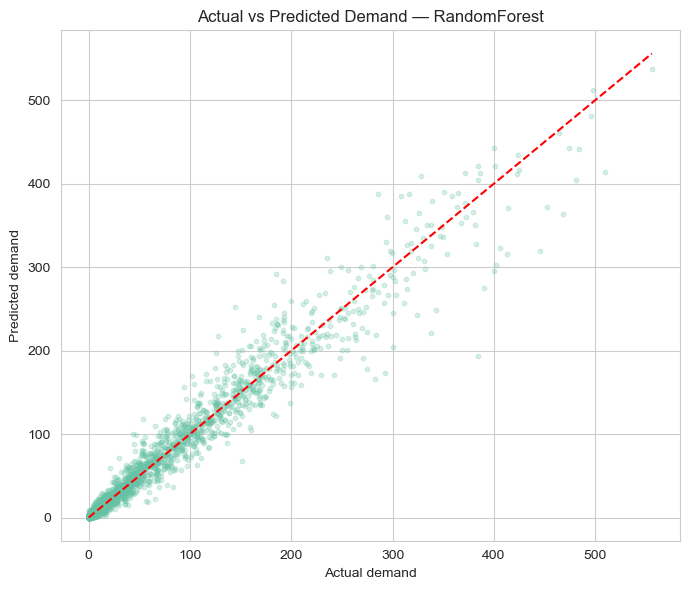

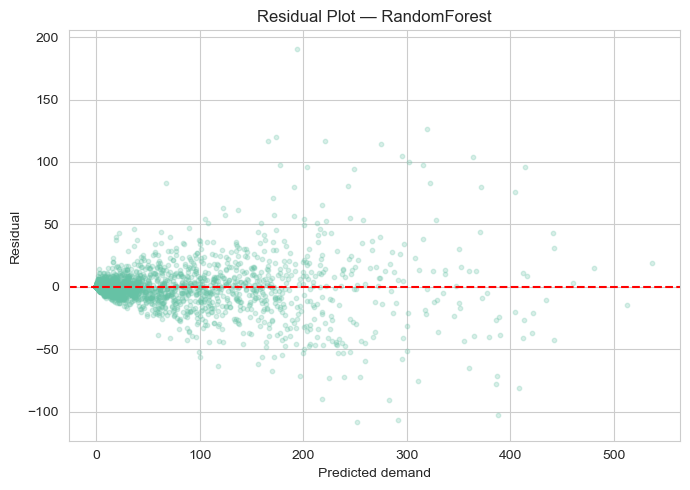

In [73]:
rng = np.random.default_rng(RANDOM_STATE)
n_plot = min(MAX_PLOT_POINTS, len(y_test))
# Sample points so plots stay readable.
plot_idx = rng.choice(len(y_test), size=n_plot, replace=False)
y_plot = y_test.to_numpy()[plot_idx]
pred_plot = final_pred[plot_idx]

plt.figure(figsize=(7, 6))
plt.scatter(y_plot, pred_plot, alpha=0.25, s=10)
limit = max(y_plot.max(), pred_plot.max())
plt.plot([0, limit], [0, limit], color='red', linestyle='--')
plt.xlabel('Actual demand')
plt.ylabel('Predicted demand')
plt.title(f'Actual vs Predicted Demand — {final_model_name}')
plt.tight_layout()
plt.savefig(OUT_DIR / 'actual_vs_predicted.png', dpi=150)
plt.show()

plt.figure(figsize=(7, 5))
# Residuals show model under- and over-prediction.
residuals = y_plot - pred_plot
plt.scatter(pred_plot, residuals, alpha=0.25, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted demand')
plt.ylabel('Residual')
plt.title(f'Residual Plot — {final_model_name}')
plt.tight_layout()
plt.savefig(OUT_DIR / 'residual_plot.png', dpi=150)
plt.show()

## 10. Feature Importance

For Random Forest, we use built-in feature importance. For Boosting, Poisson, or Ridge, we use permutation importance on a sample of the test set.

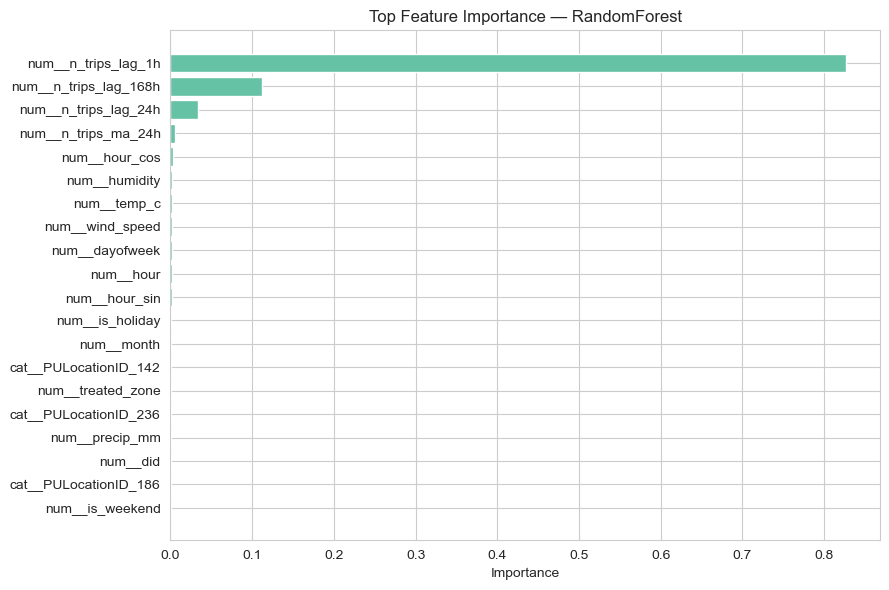

,feature,importance
12,num__n_trips_lag_1h,0.827007
14,num__n_trips_lag_168h,0.112208
13,num__n_trips_lag_24h,0.034084
15,num__n_trips_ma_24h,0.005358
5,num__hour_cos,0.002513
18,num__humidity,0.002349
16,num__temp_c,0.002144
19,num__wind_speed,0.002130
1,num__dayofweek,0.002124
0,num__hour,0.002000


In [74]:
def get_feature_importance(model, model_name):
    regressor = model.named_steps['model']

    # Tree models have built-in importance; otherwise use permutation importance.
    if hasattr(regressor, 'feature_importances_'):
        feature_names = model.named_steps['preprocess'].get_feature_names_out()
        importance = regressor.feature_importances_
        importance_df = pd.DataFrame({'feature': feature_names, 'importance': importance})
    else:
        sample_n = min(5_000, len(X_test))
        X_sample = X_test.sample(sample_n, random_state=RANDOM_STATE)
        y_sample = y_test.loc[X_sample.index]
        result = permutation_importance(
            model,
            X_sample,
            y_sample,
            n_repeats=5,
            scoring='neg_mean_absolute_error',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        importance_df = pd.DataFrame({
            'feature': X_test.columns,
            'importance': result.importances_mean,
        })

    return importance_df.sort_values('importance', ascending=False).head(20)


importance_df = get_feature_importance(final_model, final_model_name)
importance_df.to_csv(OUT_DIR / 'feature_importance.csv', index=False)

plt.figure(figsize=(9, 6))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1])
plt.xlabel('Importance')
plt.title(f'Top Feature Importance — {final_model_name}')
plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_importance.png', dpi=150)
plt.show()

importance_df

## 11. Save Modeling Summary

This text file is written so the modeling results can be copied into the final report.

In [75]:
# Save top predictors for the written summary.
top_features = ', '.join(importance_df['feature'].astype(str).head(8))

metrics_text = (
    f"Final model: {final_model_name}\n"
    f"MAE: {final_metrics['MAE']:.4f}\n"
    f"RMSE: {final_metrics['RMSE']:.4f}\n"
    f"R2: {final_metrics['R2']:.4f}\n"
    f"SMAPE: {final_metrics['SMAPE']:.2f}%\n"
)
(OUT_DIR / 'final_model_metrics.txt').write_text(metrics_text)

summary_text = (
    "NYC Taxi Demand Modeling Summary\n\n"
    "Goal:\n"
    "Predict hourly taxi demand by pickup zone and evaluate how time, location, weather, "
    "and congestion-pricing policy features help explain demand.\n\n"
    f"Input feature matrix:\n{feature_path}\n\n"
    "Dataset:\n"
    f"Rows: {len(df_model):,}\n"
    f"Columns: {df_model.shape[1]:,}\n"
    f"Target: {target_col}\n"
    f"Time column: {time_col}\n"
    f"Training window: {train_df[time_col].min()} to {train_df[time_col].max()}\n"
    f"Testing window: {test_df[time_col].min()} to {test_df[time_col].max()}\n\n"
    "Models compared:\n"
    f"{comparison.to_string(index=False)}\n\n"
    "Selected final model:\n"
    f"{final_model_name}\n\n"
    "Reason for selection:\n"
    "The final model was selected using the time-based test set, prioritizing MAE and RMSE. "
    "This is more realistic than a random split because the project is about predicting future "
    "taxi demand during a policy change period.\n\n"
    "Most important predictors:\n"
    f"{top_features}\n\n"
    "Interpretation for congestion-pricing story:\n"
    "Important time features show predictable commuting and nightlife demand patterns. "
    "Spatial features such as borough, pickup zone, CBD/treatment indicators, and zone clusters "
    "capture where demand is concentrated. Policy features such as post_policy, treated_zone, "
    "and did help compare post-policy demand changes for CBD-related zones versus other areas. "
    "Weather and holiday variables control for short-term demand shocks.\n\n"
    "Limitations:\n"
    "- The model is predictive, not a complete causal estimate of congestion pricing.\n"
    "- Results depend on the quality of zone-hour aggregation and lag features.\n"
    "- Lag features are strong predictors but may dominate policy variables.\n"
    "- Citi Bike features are optional and only included if they exist in the feature matrix.\n"
)
(OUT_DIR / 'modeling_summary.txt').write_text(summary_text)

print(metrics_text)
print('Saved outputs to:', OUT_DIR)

Final model: RandomForest
MAE: 2.5241
RMSE: 8.5020
R2: 0.9697
SMAPE: 143.12%

Saved outputs to: /Users/jason/Documents/5243 final project/outputs/modeling


## 12. Simple Prediction Interface

This function gives teammates a small `predict(X)` style interface for stacking, presentation demos, or a Streamlit app.

In [76]:
# Small wrapper for using the saved final model later.
def predict_demand(new_data):
    """Predict zone-hour taxi demand using the saved final model."""
    model = joblib.load(MODEL_DIR / 'final_model.pkl')
    return np.clip(model.predict(new_data), 0, None)

print('Example usage: predictions = predict_demand(X_test.head())')
print(predict_demand(X_test.head()))

Example usage: predictions = predict_demand(X_test.head())
[1.25180359e+00 1.57557183e-01 6.26981640e-01 3.83358645e+02
 9.10068688e-01]


## Modeling Deliverables

After running the notebook, the main files are:

- `models/poisson_model.pkl`
- `models/random_forest_model.pkl`
- `models/boosting_model.pkl`
- `models/final_model.pkl`
- `outputs/modeling/model_comparison.csv`
- `outputs/modeling/final_model_metrics.txt`
- `outputs/modeling/actual_vs_predicted.png`
- `outputs/modeling/residual_plot.png`
- `outputs/modeling/feature_importance.png`
- `outputs/modeling/modeling_summary.txt`